# Algoritmo genético APS — versión mejorada para comparación

Esta versión parte de la versión corregida y añade mejoras orientadas a análisis de TFM y validación del algoritmo:

- Modo de experimentación parametrizable (`EXPERIMENTO_NOMBRE`, `MAX_ORDENES`, `PESO_FECHA`, generaciones y población).
- Calendario laboral configurable: horas de trabajo por día y trabajo/no trabajo en fines de semana.
- Semillas heurísticas adicionales: EDD, SPT y CR (Critical Ratio).
- Métricas por orden: fecha fin, tardanza, flujo y estado a tiempo/tarde.
- Métricas por recurso: carga, utilización, número de operaciones y ventana de actividad.
- Exportación de ficheros separados: secuencia, métricas globales, métricas por orden, métricas por recurso y validación.
- Se conserva el formato de salida compatible con `LPA_GAM.csv` y `LPA_GSM.csv`.

Este archivo es deliberadamente independiente para poder compararlo con `aps_genetico.ipynb`.

## 1. Imports y configuración

In [1]:
from pathlib import Path
from datetime import datetime, timedelta
from collections import OrderedDict, defaultdict
import math
import random
import time
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

RANDOM_SEED = 42
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 180)

## 2. Resolución robusta de rutas

In [2]:
def resolver_carpeta_ejecucion():
    """Devuelve la carpeta del archivo/notebook que se está ejecutando."""
    archivo_actual = globals().get("__file__")
    if archivo_actual and Path(archivo_actual).exists():
        return Path(archivo_actual).resolve().parent

    notebook_name = "aps_genetico.ipynb"
    cwd = Path.cwd().resolve()
    candidatos = [cwd / notebook_name, cwd / "tfm" / "algoritmos" / notebook_name]
    try:
        candidatos.extend(cwd.glob(f"**/{notebook_name}"))
    except OSError:
        pass

    for ruta in candidatos:
        if ruta.exists():
            return ruta.resolve().parent
    return cwd


def resolver_rutas():
    """Localiza los CSV desde la carpeta del codigo, su padre y rutas conocidas."""
    carpeta_codigo = resolver_carpeta_ejecucion()
    candidatos_raiz = [
        carpeta_codigo,
        carpeta_codigo.parent,
        Path("/workspace/tfm"),
        Path("/opt/projects/tfm"),
        Path("/workspace/projects/tfm"),
        Path("/mnt/data"),
        Path.cwd(),
    ]
    subdirs_datos = ["datos_ofuscados", ""]
    output_dir = carpeta_codigo / "output"

    for raiz in candidatos_raiz:
        for sub in subdirs_datos:
            data_dir = raiz / sub if sub else raiz
            if (data_dir / "PLAN.csv").exists() and (data_dir / "CCP.csv").exists():
                return raiz, data_dir, output_dir
    raise FileNotFoundError("No se encontraron PLAN.csv y CCP.csv en las rutas esperadas.")

ROOT_DIR, DATA_DIR, OUTPUT_DIR = resolver_rutas()
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

PLAN_PATH = DATA_DIR / "PLAN.csv"
CCP_PATH = DATA_DIR / "CCP.csv"
LPA_GAM_PATH = DATA_DIR / "LPA_GAM.csv" if (DATA_DIR / "LPA_GAM.csv").exists() else ROOT_DIR / "LPA_GAM.csv"
LPA_GSM_PATH = DATA_DIR / "LPA_GSM.csv" if (DATA_DIR / "LPA_GSM.csv").exists() else ROOT_DIR / "LPA_GSM.csv"

print("ROOT_DIR :", ROOT_DIR)
print("DATA_DIR :", DATA_DIR)
print("OUTPUT_DIR:", OUTPUT_DIR)
print("PLAN     :", PLAN_PATH)
print("CCP      :", CCP_PATH)
print("LPA_GAM  :", LPA_GAM_PATH)
print("LPA_GSM  :", LPA_GSM_PATH)

ROOT_DIR : /opt/projects/tfm
DATA_DIR : /opt/projects/tfm/datos_ofuscados
OUTPUT_DIR: /opt/projects/tfm/algoritmos/output
PLAN     : /opt/projects/tfm/datos_ofuscados/PLAN.csv
CCP      : /opt/projects/tfm/datos_ofuscados/CCP.csv
LPA_GAM  : /opt/projects/tfm/datos_ofuscados/LPA_GAM.csv
LPA_GSM  : /opt/projects/tfm/datos_ofuscados/LPA_GSM.csv


## 3. Carga y primera inspección de datos

In [3]:
def leer_csv(path, **kwargs):
    return pd.read_csv(path, sep=";", encoding="utf-8-sig", **kwargs)

plan_df = leer_csv(
    PLAN_PATH,
    parse_dates=["FECHA_PROVEEDOR", "FECHA_ENTREGA"],
)
ccp_df = leer_csv(CCP_PATH)
lpa_gam = leer_csv(
    LPA_GAM_PATH,
    parse_dates=["COMIENZO_OPERACION", "FIN_OPERACION", "FECHA_CALCULO_PLAN"],
)
lpa_gsm = leer_csv(
    LPA_GSM_PATH,
    parse_dates=["COMIENZO_OPERACION", "FIN_OPERACION", "FECHA_CALCULO_PLAN"],
)
lpa_df = pd.concat([lpa_gam, lpa_gsm], ignore_index=True)

print("PLAN:", plan_df.shape)
print("CCP :", ccp_df.shape)
print("LPA :", lpa_df.shape)
print("\nColumnas PLAN:", list(plan_df.columns))
print("Columnas CCP :", list(ccp_df.columns))
print("Columnas LPA :", list(lpa_df.columns))

PLAN: (14983, 8)
CCP : (35789, 10)
LPA : (12829, 13)

Columnas PLAN: ['ORDEN', 'PARTNUMBER', 'CANTIDAD', 'CENTRO', 'FECHA_PROVEEDOR', 'FECHA_PROVEEDOR_REAL', 'FECHA_ENTREGA', 'CLIENTE']
Columnas CCP : ['PARTNUMBER', 'OPERACION', 'POSTURA', 'RECURSO', 'TECNOLOGIA', 'CENTRO_MECANIZADO', 'PIEZAS_SIMULTANEAS', 'TIEMPO_FIJO_MIN', 'TIEMPO_VARIABLE_MIN', 'OEE']
Columnas LPA : ['ORDEN', 'OPERACION', 'RECURSO', 'PARTNUMBER', 'CANTIDAD', 'COMIENZO_OPERACION', 'FIN_OPERACION', 'TIEMPO_PREPARACION', 'TIEMPO_PROCESO', 'GRUPO_RECURSO', 'MULTIPLICIDAD', 'DURACION_CCP', 'FECHA_CALCULO_PLAN']


## 4. Limpieza de órdenes sin datos CCP, sin tiempos CCP o sin OEE

Limpieza de órdenes con fecha de proveedor en atraso configurable (por defecto, True)

In [4]:
# Parametros configurables del alcance de planificacion.
# MODO_PLANIFICACION_ORDENES:
# - "TODAS": planifica todas las ordenes de PLAN que superen la limpieza de datos.
# - "SOLO_LPA": planifica solo las ordenes de PLAN cuyo codigo ORDEN aparece en LPA_GAM o LPA_GSM.
MODO_PLANIFICACION_ORDENES = "SOLO_LPA"
ELIMINAR_ORDENES_FECHA_PROVEEDOR_ATRASADA = True
FECHA_REFERENCIA_ATRASO_PROVEEDOR = pd.Timestamp(lpa_df["FECHA_CALCULO_PLAN"].dropna().min()).floor("D")

MODOS_PLANIFICACION_VALIDOS = {"TODAS", "SOLO_LPA"}
if MODO_PLANIFICACION_ORDENES not in MODOS_PLANIFICACION_VALIDOS:
    raise ValueError(
        "MODO_PLANIFICACION_ORDENES debe ser uno de "
        f"{sorted(MODOS_PLANIFICACION_VALIDOS)}"
    )

# Primero se detectan los PARTNUMBER cuya ruta CCP no es utilizable.
# Se invalidan si alguna operacion no tiene tiempos u OEE usable.
tiempo_cols = ["TIEMPO_FIJO_MIN", "TIEMPO_VARIABLE_MIN"]
tiempos_ccp = ccp_df[tiempo_cols].apply(
    lambda col: pd.to_numeric(col.astype(str).str.replace(",", ".", regex=False), errors="coerce")
)
oee_ccp = pd.to_numeric(
    ccp_df["OEE"].astype(str).str.replace(",", ".", regex=False),
    errors="coerce",
)

partnumber_ccp = ccp_df["PARTNUMBER"].astype("string")
partnumbers_ccp = set(partnumber_ccp.dropna().astype(str))
mascara_ccp_tiempo_cero = tiempos_ccp.fillna(0.0).sum(axis=1).le(0.0)
mascara_ccp_oee_invalido = oee_ccp.isna() | oee_ccp.eq(0)
partnumbers_ccp_tiempo_cero = set(
    partnumber_ccp[mascara_ccp_tiempo_cero & partnumber_ccp.notna()].astype(str)
)
partnumbers_ccp_oee_invalido = set(
    partnumber_ccp[mascara_ccp_oee_invalido & partnumber_ccp.notna()].astype(str)
)
partnumbers_ccp_validos = partnumbers_ccp - partnumbers_ccp_tiempo_cero - partnumbers_ccp_oee_invalido

# Despues se filtran las ordenes de PLAN antes de ejecutar cualquier parte del algoritmo.
# Primero se aplica el alcance elegido: todas las ordenes o solo las ya presentes en LPA.
n_plan_original = len(plan_df)
ordenes_lpa = set(lpa_df["ORDEN"].dropna().astype(str))
orden_plan = plan_df["ORDEN"].astype("string")
mascara_plan_en_lpa = orden_plan.notna() & orden_plan.astype(str).isin(ordenes_lpa)
n_ordenes_plan_fuera_lpa = int((~mascara_plan_en_lpa).sum())
ordenes_plan_fuera_lpa = plan_df.loc[
    ~mascara_plan_en_lpa,
    ["ORDEN", "PARTNUMBER"],
].copy()
ordenes_plan_fuera_lpa["MOTIVO"] = "ORDEN no aparece en LPA_GAM ni LPA_GSM"

if MODO_PLANIFICACION_ORDENES == "SOLO_LPA":
    plan_df = plan_df.loc[mascara_plan_en_lpa].reset_index(drop=True)
else:
    ordenes_plan_fuera_lpa = ordenes_plan_fuera_lpa.iloc[0:0].copy()

# Se eliminan las ordenes sin datos CCP, con tiempos CCP a cero o con OEE CCP sin valor/cero.
partnumber_plan = plan_df["PARTNUMBER"].astype("string")
mascara_plan_con_ccp = partnumber_plan.notna() & partnumber_plan.isin(partnumbers_ccp)
mascara_plan_con_ccp_valido = partnumber_plan.notna() & partnumber_plan.isin(partnumbers_ccp_validos)
mascara_plan_ccp_tiempo_cero = mascara_plan_con_ccp & partnumber_plan.isin(partnumbers_ccp_tiempo_cero)
mascara_plan_ccp_oee_invalido = mascara_plan_con_ccp & partnumber_plan.isin(partnumbers_ccp_oee_invalido)

ordenes_plan_sin_ccp = plan_df.loc[
    ~mascara_plan_con_ccp,
    ["ORDEN", "PARTNUMBER"],
].copy()
ordenes_plan_sin_ccp["MOTIVO"] = "PARTNUMBER no aparece en CCP"

ordenes_plan_ccp_tiempo_cero = plan_df.loc[
    mascara_plan_ccp_tiempo_cero,
    ["ORDEN", "PARTNUMBER"],
].copy()
ordenes_plan_ccp_tiempo_cero["MOTIVO"] = "PARTNUMBER con duracion base CCP a cero"

ordenes_plan_ccp_oee_invalido = plan_df.loc[
    mascara_plan_ccp_oee_invalido,
    ["ORDEN", "PARTNUMBER"],
].copy()
ordenes_plan_ccp_oee_invalido["MOTIVO"] = "PARTNUMBER con OEE CCP sin valor o cero"

def motivo_descarte_plan(partnumber):
    if pd.isna(partnumber):
        return "PARTNUMBER vacio en PLAN"

    pn = str(partnumber)
    if pn not in partnumbers_ccp:
        return "PARTNUMBER no aparece en CCP"

    motivos = []
    if pn in partnumbers_ccp_tiempo_cero:
        motivos.append("duracion base CCP a cero")
    if pn in partnumbers_ccp_oee_invalido:
        motivos.append("OEE CCP sin valor o cero")
    return "; ".join(motivos)

ordenes_plan_descartadas = plan_df.loc[
    ~mascara_plan_con_ccp_valido,
    ["ORDEN", "PARTNUMBER"],
].copy()
ordenes_plan_descartadas["MOTIVO"] = ordenes_plan_descartadas["PARTNUMBER"].apply(motivo_descarte_plan)
ordenes_plan_descartadas = pd.concat(
    [ordenes_plan_fuera_lpa, ordenes_plan_descartadas],
    ignore_index=True,
    sort=False,
)

plan_df = plan_df.loc[mascara_plan_con_ccp_valido].reset_index(drop=True)

# Opcionalmente se eliminan ordenes cuya fecha de proveedor ya esta vencida
# respecto a la fecha de referencia del plan.
fecha_proveedor_plan = pd.to_datetime(plan_df["FECHA_PROVEEDOR"], errors="coerce")
mascara_plan_fecha_proveedor_atrasada = fecha_proveedor_plan < FECHA_REFERENCIA_ATRASO_PROVEEDOR
ordenes_plan_fecha_proveedor_atrasada = plan_df.loc[
    mascara_plan_fecha_proveedor_atrasada,
    ["ORDEN", "PARTNUMBER", "FECHA_PROVEEDOR"],
].copy()
ordenes_plan_fecha_proveedor_atrasada["MOTIVO"] = (
    "FECHA_PROVEEDOR anterior a " + str(FECHA_REFERENCIA_ATRASO_PROVEEDOR.date())
)

if ELIMINAR_ORDENES_FECHA_PROVEEDOR_ATRASADA:
    ordenes_plan_descartadas = pd.concat(
        [ordenes_plan_descartadas, ordenes_plan_fecha_proveedor_atrasada],
        ignore_index=True,
        sort=False,
    )
    plan_df = plan_df.loc[~mascara_plan_fecha_proveedor_atrasada].reset_index(drop=True)

print("Modo planificacion ordenes:", MODO_PLANIFICACION_ORDENES)
print("Ordenes PLAN antes de limpieza:", n_plan_original)
print("Ordenes PLAN fuera de LPA:", n_ordenes_plan_fuera_lpa)
print("Ordenes eliminadas sin PARTNUMBER en CCP:", len(ordenes_plan_sin_ccp))
print("Ordenes afectadas por duracion base CCP a cero:", len(ordenes_plan_ccp_tiempo_cero))
print("Ordenes afectadas por OEE CCP sin valor o cero:", len(ordenes_plan_ccp_oee_invalido))
print("Eliminar ordenes con FECHA_PROVEEDOR atrasada:", ELIMINAR_ORDENES_FECHA_PROVEEDOR_ATRASADA)
print("Fecha referencia atraso proveedor:", FECHA_REFERENCIA_ATRASO_PROVEEDOR.date())
print("Ordenes con FECHA_PROVEEDOR atrasada:", len(ordenes_plan_fecha_proveedor_atrasada))
print("Ordenes descartadas totales:", len(ordenes_plan_descartadas))
print("Ordenes PLAN despues de limpieza:", len(plan_df))
ordenes_plan_descartadas.head()

Modo planificacion ordenes: SOLO_LPA
Ordenes PLAN antes de limpieza: 14983
Ordenes PLAN fuera de LPA: 10820
Ordenes eliminadas sin PARTNUMBER en CCP: 25
Ordenes afectadas por duracion base CCP a cero: 49
Ordenes afectadas por OEE CCP sin valor o cero: 166
Eliminar ordenes con FECHA_PROVEEDOR atrasada: True
Fecha referencia atraso proveedor: 2026-05-19
Ordenes con FECHA_PROVEEDOR atrasada: 1599
Ordenes descartadas totales: 12655
Ordenes PLAN despues de limpieza: 2328


,ORDEN,PARTNUMBER,MOTIVO,FECHA_PROVEEDOR
0,ORDEN_0,PARTNUMBER_0,ORDEN no aparece en LPA_GAM ni LPA_GSM,NaT
1,ORDEN_1,PARTNUMBER_1,ORDEN no aparece en LPA_GAM ni LPA_GSM,NaT
2,ORDEN_3,PARTNUMBER_3,ORDEN no aparece en LPA_GAM ni LPA_GSM,NaT
3,ORDEN_4,PARTNUMBER_4,ORDEN no aparece en LPA_GAM ni LPA_GSM,NaT
4,ORDEN_5,PARTNUMBER_5,ORDEN no aparece en LPA_GAM ni LPA_GSM,NaT


## 5. Generación de RECURSOS.csv desde LPA_GAM y LPA_GSM

In [5]:
recursos_path = OUTPUT_DIR / "RECURSOS.csv"

def normalizar_recursos(df):
    return (
        df[["RECURSO", "GRUPO_RECURSO"]]
        .dropna()
        .astype(str)
        .drop_duplicates()
        .sort_values(["GRUPO_RECURSO", "RECURSO"])
        .reset_index(drop=True)
    )

# RECURSOS.csv debe salir de las apariciones RECURSO/GRUPO_RECURSO de LPA_GAM y LPA_GSM.
if recursos_path.exists():
    recursos_df = normalizar_recursos(leer_csv(recursos_path))
    print("RECURSOS.csv cargado desde:", recursos_path)
else:
    recursos_df = normalizar_recursos(lpa_df)
    recursos_df.to_csv(recursos_path, sep=";", index=False)
    print("RECURSOS.csv guardado en:", recursos_path)

recursos_por_grupo = (
    recursos_df.groupby("GRUPO_RECURSO")["RECURSO"]
    .apply(lambda s: sorted(set(s.astype(str))))
    .to_dict()
)
maquina_to_groups = (
    recursos_df.groupby("RECURSO")["GRUPO_RECURSO"]
    .apply(lambda s: sorted(set(s.astype(str))))
    .to_dict()
)
available_groups = set(recursos_por_grupo)

print("Pares recurso/grupo:", len(recursos_df))
print("Máquinas únicas:", recursos_df["RECURSO"].nunique())
print("Grupos únicos:", recursos_df["GRUPO_RECURSO"].nunique())
recursos_df.head()

RECURSOS.csv cargado desde: /opt/projects/tfm/algoritmos/output/RECURSOS.csv
Pares recurso/grupo: 229
Máquinas únicas: 153
Grupos únicos: 153


,RECURSO,GRUPO_RECURSO
0,RECURSO_170,GRUPO_RECURSO_0
1,RECURSO_177,GRUPO_RECURSO_0
2,RECURSO_187,GRUPO_RECURSO_0
3,RECURSO_199,GRUPO_RECURSO_0
4,RECURSO_187,GRUPO_RECURSO_1


## 6. Inferencia de GRUPO_RECURSO para los registros CCP

In [6]:
def moda_o_primero(serie):
    vc = serie.dropna().astype(str).value_counts()
    return vc.index[0] if len(vc) else pd.NA

# En el CCP real recibido no existe una columna GRUPO_RECURSO; aparece como RECURSO.
# Por eso se infiere el grupo compatible usando las secuencias Asprova como referencia.
lpa_key_to_group = (
    lpa_df.groupby(["PARTNUMBER", "OPERACION"])["GRUPO_RECURSO"]
    .agg(moda_o_primero)
    .to_dict()
)

# Fallback: para cada RECURSO de CCP, grupo más observado al cruzar CCP con LPA por partnumber/operación.
joined_lpa_ccp = lpa_df[["PARTNUMBER", "OPERACION", "GRUPO_RECURSO"]].merge(
    ccp_df[["PARTNUMBER", "OPERACION", "RECURSO"]].rename(columns={"RECURSO": "CCP_RECURSO"}),
    on=["PARTNUMBER", "OPERACION"],
    how="inner",
)
ccp_resource_to_group = (
    joined_lpa_ccp.groupby("CCP_RECURSO")["GRUPO_RECURSO"]
    .agg(moda_o_primero)
    .to_dict()
)

def inferir_grupo_ccp(row):
    key = (row["PARTNUMBER"], row["OPERACION"])
    if key in lpa_key_to_group:
        return lpa_key_to_group[key], "lpa_partnumber_operacion"

    recurso_ccp = str(row["RECURSO"])
    if recurso_ccp in ccp_resource_to_group:
        return ccp_resource_to_group[recurso_ccp], "ccp_recurso_dominante"

    if recurso_ccp in maquina_to_groups and maquina_to_groups[recurso_ccp]:
        return maquina_to_groups[recurso_ccp][0], "maquina_directa"

    grupo_por_numero = recurso_ccp.replace("RECURSO_", "GRUPO_RECURSO_")
    if grupo_por_numero in available_groups:
        return grupo_por_numero, "conversion_numerica"

    return pd.NA, "sin_mapeo"

mapeo = ccp_df.apply(inferir_grupo_ccp, axis=1, result_type="expand")
ccp_df["GRUPO_RECURSO"] = mapeo[0]
ccp_df["MAPEO_GRUPO"] = mapeo[1]

print("Método de mapeo CCP -> GRUPO_RECURSO:")
print(ccp_df["MAPEO_GRUPO"].value_counts(dropna=False))
print("\nRegistros CCP sin grupo válido:", int((~ccp_df["GRUPO_RECURSO"].isin(available_groups)).sum()))
print("Registros CCP totales:", len(ccp_df))
ccp_df.head()

Método de mapeo CCP -> GRUPO_RECURSO:
MAPEO_GRUPO
ccp_recurso_dominante       17519
conversion_numerica         13531
lpa_partnumber_operacion     4711
sin_mapeo                      15
maquina_directa                13
Name: count, dtype: int64

Registros CCP sin grupo válido: 15
Registros CCP totales: 35789


,PARTNUMBER,OPERACION,POSTURA,RECURSO,TECNOLOGIA,CENTRO_MECANIZADO,PIEZAS_SIMULTANEAS,TIEMPO_FIJO_MIN,TIEMPO_VARIABLE_MIN,OEE,GRUPO_RECURSO,MAPEO_GRUPO
0,PARTNUMBER_6373,800020,POSTURA_0,RECURSO_0,TECNOLOGIA_0,CENTRO_MECANIZADO_0,1,10.0,10.89,68.1,GRUPO_RECURSO_2,ccp_recurso_dominante
1,PARTNUMBER_6374,800020,POSTURA_0,RECURSO_0,TECNOLOGIA_0,CENTRO_MECANIZADO_0,1,10.0,10.89,68.1,GRUPO_RECURSO_2,ccp_recurso_dominante
2,PARTNUMBER_6375,1300020,POSTURA_0,RECURSO_0,TECNOLOGIA_1,CENTRO_MECANIZADO_0,1,360.0,25.00,45.0,GRUPO_RECURSO_2,ccp_recurso_dominante
3,PARTNUMBER_6375,1300030,POSTURA_1,RECURSO_0,TECNOLOGIA_1,CENTRO_MECANIZADO_0,1,120.0,10.00,40.0,GRUPO_RECURSO_2,ccp_recurso_dominante
4,PARTNUMBER_6376,800020,POSTURA_0,RECURSO_1,TECNOLOGIA_1,CENTRO_MECANIZADO_0,1,120.0,50.00,40.0,GRUPO_RECURSO_18,ccp_recurso_dominante


## 7. Construcción de rutas de fabricación por partnumber

In [7]:
# Normalización de tipos numéricos.
ccp_valid = ccp_df[ccp_df["GRUPO_RECURSO"].isin(available_groups)].copy()
for col in ["OPERACION", "PIEZAS_SIMULTANEAS"]:
    ccp_valid[col] = pd.to_numeric(ccp_valid[col], errors="coerce").fillna(0).astype(int)
for col in ["TIEMPO_FIJO_MIN", "TIEMPO_VARIABLE_MIN", "OEE"]:
    ccp_valid[col] = pd.to_numeric(ccp_valid[col], errors="coerce").fillna(0.0)

# Rutas por partnumber. Si hay varias alternativas para un mismo PARTNUMBER/OPERACION,
# se conservan todas y el decodificador elegirá la que termine antes según disponibilidad.
routes_by_pn = {}
for pn, dfpn in ccp_valid.sort_values(["PARTNUMBER", "OPERACION"]).groupby("PARTNUMBER"):
    ops = []
    for op_code, dfop in dfpn.groupby("OPERACION", sort=True):
        alternativas = []
        for _, r in dfop.iterrows():
            oee = float(r["OEE"]) if float(r["OEE"]) > 0 else 100.0
            multiplicidad = int(r["PIEZAS_SIMULTANEAS"]) if int(r["PIEZAS_SIMULTANEAS"]) > 0 else 1
            alternativas.append({
                "operacion": int(op_code),
                "grupo": str(r["GRUPO_RECURSO"]),
                "ccp_recurso": str(r["RECURSO"]),
                "postura": str(r.get("POSTURA", "")),
                "tecnologia": str(r.get("TECNOLOGIA", "")),
                "centro_mecanizado": str(r.get("CENTRO_MECANIZADO", "")),
                "tfijo": float(r["TIEMPO_FIJO_MIN"]),
                "tvar": float(r["TIEMPO_VARIABLE_MIN"]),
                "oee": oee,
                "mul": multiplicidad,
                "mapeo_grupo": str(r.get("MAPEO_GRUPO", "")),
            })
        ops.append({"operacion": int(op_code), "alternativas": alternativas})
    routes_by_pn[str(pn)] = ops

print("Partnumbers con ruta CCP válida:", len(routes_by_pn))
print("Operaciones CCP válidas:", len(ccp_valid))

Partnumbers con ruta CCP válida: 11164
Operaciones CCP válidas: 35774


## 8. Construcción de órdenes planificables desde PLAN.csv

In [8]:
# Parámetros de ejecución.
# Para ejecutar toda la carga, deja MAX_ORDENES = None. Para pruebas rápidas, usa por ejemplo 500 o 1000.
MAX_ORDENES = None

# Fecha de arranque del plan. Se toma la primera fecha de cálculo de los ejemplos Asprova;
# se puede sustituir por la fecha/hora real de lanzamiento del APS.
PLAN_START = pd.Timestamp(lpa_df["FECHA_CALCULO_PLAN"].dropna().min()).floor("D")

# Calendario laboral de las maquinas.
HORAS_TRABAJO_DIA = 24.0
TRABAJA_FINES_SEMANA = False
HORA_INICIO_TURNO = 0.0

if not (0 < HORAS_TRABAJO_DIA <= 24):
    raise ValueError("HORAS_TRABAJO_DIA debe estar entre 0 y 24.")
if not (0 <= HORA_INICIO_TURNO < 24):
    raise ValueError("HORA_INICIO_TURNO debe estar entre 0 y 24.")
if HORA_INICIO_TURNO + HORAS_TRABAJO_DIA > 24:
    raise ValueError("El turno configurado no puede cruzar medianoche.")

MINUTOS_TRABAJO_DIA = float(HORAS_TRABAJO_DIA) * 60.0
TURNO_INICIO_OFFSET = pd.to_timedelta(float(HORA_INICIO_TURNO), unit="h")


def es_dia_laborable(ts):
    ts = pd.Timestamp(ts)
    return bool(TRABAJA_FINES_SEMANA) or ts.weekday() < 5


def inicio_turno_dia(ts):
    return pd.Timestamp(ts).normalize() + TURNO_INICIO_OFFSET


def fin_turno_dia(ts):
    return inicio_turno_dia(ts) + pd.to_timedelta(MINUTOS_TRABAJO_DIA, unit="m")


def siguiente_inicio_turno(ts):
    return pd.Timestamp(ts).normalize() + pd.Timedelta(days=1) + TURNO_INICIO_OFFSET


def ajustar_a_calendario_laboral(ts):
    ts = pd.Timestamp(ts)
    while True:
        if not es_dia_laborable(ts):
            ts = siguiente_inicio_turno(ts)
            continue
        inicio = inicio_turno_dia(ts)
        fin = fin_turno_dia(ts)
        if ts < inicio:
            return inicio
        if ts < fin:
            return ts
        ts = siguiente_inicio_turno(ts)


PLAN_START_LABORAL = ajustar_a_calendario_laboral(PLAN_START)


def sumar_dias_laborables(fecha_inicio, n_dias):
    fecha_inicio = pd.Timestamp(fecha_inicio).normalize()
    n_dias = int(n_dias)
    if n_dias <= 0:
        return fecha_inicio
    if TRABAJA_FINES_SEMANA:
        return fecha_inicio + pd.Timedelta(days=n_dias)
    return fecha_inicio + pd.offsets.BDay(n_dias)


def dias_laborables_entre(fecha_inicio, fecha_fin):
    inicio = pd.Timestamp(fecha_inicio).normalize().date()
    fin = pd.Timestamp(fecha_fin).normalize().date()
    if fin <= inicio:
        return 0
    if TRABAJA_FINES_SEMANA:
        return (pd.Timestamp(fin) - pd.Timestamp(inicio)).days
    return int(np.busday_count(np.datetime64(inicio), np.datetime64(fin)))


def minutos_laborales_hasta_fecha(ts):
    if pd.isna(ts):
        return math.inf
    ts = pd.Timestamp(ts)
    if ts < PLAN_START_LABORAL:
        return -max(0.0, (PLAN_START_LABORAL - ts).total_seconds() / 60.0)

    minutos = dias_laborables_entre(PLAN_START_LABORAL, ts) * MINUTOS_TRABAJO_DIA
    if es_dia_laborable(ts):
        inicio = inicio_turno_dia(ts)
        fin = fin_turno_dia(ts)
        if ts <= inicio:
            parcial = 0.0
        elif ts >= fin:
            parcial = MINUTOS_TRABAJO_DIA
        else:
            parcial = (ts - inicio).total_seconds() / 60.0
        minutos += parcial
    return float(minutos)


def fecha_plan_desde_minutos_laborales(minutos_desde_inicio, como_fin=True):
    if not math.isfinite(float(minutos_desde_inicio)):
        return pd.NaT
    minutos = float(minutos_desde_inicio)
    if minutos <= 0:
        return PLAN_START_LABORAL + pd.to_timedelta(minutos, unit="m")

    dia = max(MINUTOS_TRABAJO_DIA, 1.0)
    dias_completos = int(math.floor((minutos + 1e-7) / dia))
    resto = minutos - dias_completos * dia
    if abs(resto) <= 1e-6:
        resto = 0.0
    elif abs(resto - dia) <= 1e-6:
        dias_completos += 1
        resto = 0.0

    if como_fin and resto <= 1e-9:
        dias_completos -= 1
        resto = dia

    fecha = sumar_dias_laborables(PLAN_START_LABORAL, dias_completos)
    return inicio_turno_dia(fecha) + pd.to_timedelta(resto, unit="m")


def iterar_segmentos_laborales(min_inicio, min_fin):
    restante = max(0.0, float(min_fin) - float(min_inicio))
    cursor = float(min_inicio)
    dia = max(MINUTOS_TRABAJO_DIA, 1.0)
    while restante > 1e-7:
        # Snap a fronteras de dia laboral para evitar tramos espurios en fin de semana por precision flotante.
        resto_dia = cursor % dia
        if abs(resto_dia) <= 1e-6 or abs(resto_dia - dia) <= 1e-6:
            cursor = round(cursor / dia) * dia

        inicio = fecha_plan_desde_minutos_laborales(cursor, como_fin=False)
        if pd.isna(inicio) or not es_dia_laborable(inicio):
            cursor = math.ceil((cursor + 1e-7) / dia) * dia
            continue

        fin_turno = fin_turno_dia(inicio)
        disponible = max(0.0, (fin_turno - inicio).total_seconds() / 60.0)
        if disponible <= 1e-7:
            cursor = math.ceil((cursor + 1e-7) / dia) * dia
            continue

        duracion = min(restante, disponible)
        if duracion <= 1e-7:
            break
        fin = inicio + pd.to_timedelta(duracion, unit="m")
        yield inicio, fin, duracion
        cursor += duracion
        restante -= duracion

order_operations = OrderedDict()
skipped_orders = []

for row_idx, row in plan_df.iterrows():
    if MAX_ORDENES is not None and len(order_operations) >= MAX_ORDENES:
        break

    pn = str(row["PARTNUMBER"])
    if pn not in routes_by_pn:
        skipped_orders.append({
            "row_idx": row_idx,
            "ORDEN": row.get("ORDEN"),
            "PARTNUMBER": pn,
            "motivo": "sin ruta CCP con grupo válido",
        })
        continue

    qty = float(row["CANTIDAD"]) if pd.notna(row["CANTIDAD"]) else 0.0
    ops = []
    for op in routes_by_pn[pn]:
        alternativas = []
        for alt in op["alternativas"]:
            oee_factor = 100.0 / alt["oee"] if alt["oee"] > 0 else 1.0
            t_prep = alt["tfijo"] * oee_factor
            raw_proc = qty * (alt["tvar"] / max(alt["mul"], 1))
            t_proc = raw_proc * oee_factor
            duracion_base_sin_oee = alt["tfijo"] + raw_proc
            duracion_ccp = duracion_base_sin_oee * oee_factor
            alternativas.append({
                **alt,
                "t_prep": t_prep,
                "t_proc": t_proc,
                "dur_total": t_prep + t_proc,
                "duracion_ccp": duracion_ccp,
                "duracion_base_sin_oee": duracion_base_sin_oee,
            })
        ops.append({"operacion": op["operacion"], "alternativas": alternativas})

    order_operations[row_idx] = {
        "orden": str(row["ORDEN"]),
        "pn": pn,
        "qty": qty,
        "deadline": row["FECHA_PROVEEDOR"],
        "deadline_work_min": minutos_laborales_hasta_fecha(row["FECHA_PROVEEDOR"]),
        "ops": ops,
        "n_ops": len(ops),
    }

print("PLAN_START:", PLAN_START)
print("PLAN_START_LABORAL:", PLAN_START_LABORAL)
print("Horas trabajo/dia maquinas:", HORAS_TRABAJO_DIA)
print("Trabaja fines de semana:", TRABAJA_FINES_SEMANA)
print("Órdenes planificables:", len(order_operations))
print("Órdenes omitidas por falta de ruta:", len(skipped_orders))
print("Operaciones a planificar:", sum(o["n_ops"] for o in order_operations.values()))
if skipped_orders:
    display(pd.DataFrame(skipped_orders).head(10))

PLAN_START: 2026-05-19 00:00:00
PLAN_START_LABORAL: 2026-05-19 00:00:00
Horas trabajo/dia maquinas: 24.0
Trabaja fines de semana: False
Órdenes planificables: 2328
Órdenes omitidas por falta de ruta: 0
Operaciones a planificar: 10641


## 9. Decodificador de scheduling

In [9]:
def decode_schedule(chromosome, order_operations, recursos_por_grupo):
    """Decodifica una permutación de órdenes en un plan factible.

    Para cada operación se prueba cada alternativa CCP y cada máquina del grupo.
    Se elige la combinación con menor fin de operación, respetando:
    - fin de la operación anterior de la misma orden;
    - disponibilidad de la máquina;
    - pertenencia de la máquina al GRUPO_RECURSO.
    """
    res_free = {m: 0.0 for maquinas in recursos_por_grupo.values() for m in maquinas}
    schedule = []
    order_finish = {}
    missing_ops = []

    for oidx in chromosome:
        od = order_operations.get(oidx)
        if od is None:
            continue

        cur = 0.0
        orden_ok = True

        for op in od["ops"]:
            best = None
            for alt in op["alternativas"]:
                maquinas = recursos_por_grupo.get(alt["grupo"], [])
                if not maquinas:
                    continue

                dur = alt["dur_total"]
                for maquina in maquinas:
                    start = max(cur, res_free.get(maquina, 0.0))
                    end = start + dur
                    if best is None or (end, start, dur) < (best["t_end"], best["t_start"], best["dur_total"]):
                        best = {**alt, "recurso": maquina, "t_start": start, "t_end": end}

            if best is None:
                orden_ok = False
                missing_ops.append({"oidx": oidx, "ORDEN": od["orden"], "OPERACION": op["operacion"]})
                continue

            schedule.append({
                "oidx": oidx,
                "ORDEN": od["orden"],
                "OPERACION": op["operacion"],
                "PARTNUMBER": od["pn"],
                "CANTIDAD": od["qty"],
                "RECURSO": best["recurso"],
                "GRUPO_RECURSO": best["grupo"],
                "t_start": best["t_start"],
                "t_end": best["t_end"],
                "TIEMPO_PREPARACION": best["t_prep"],
                "TIEMPO_PROCESO": best["t_proc"],
                "MULTIPLICIDAD": best["mul"],
                "DURACION_CCP": best["duracion_ccp"],
                "CCP_RECURSO": best["ccp_recurso"],
                "MAPEO_GRUPO": best["mapeo_grupo"],
            })
            res_free[best["recurso"]] = best["t_end"]
            cur = best["t_end"]

        order_finish[oidx] = cur if orden_ok else math.inf

    return schedule, order_finish, res_free, missing_ops


def compute_metrics(schedule, order_finish, order_operations, plan_start):
    if not schedule:
        return {
            "makespan_min": 0.0,
            "makespan_days": 0.0,
            "tardy_orders": len(order_operations),
            "due_orders": len(order_operations),
            "on_time_rate": 0.0,
            "workload_hours": 0.0,
            "on_time_workload_hours": 0.0,
            "on_time_workload_rate": 0.0,
            "total_late_min": 0.0,
            "max_late_min": 0.0,
            "utilization": 0.0,
            "n_ops_scheduled": 0,
            "n_active_res": 0,
        }

    makespan = max(s["t_end"] for s in schedule)
    order_workload_min = defaultdict(float)
    for s in schedule:
        order_workload_min[s["oidx"]] += max(0.0, s["t_end"] - s["t_start"])
    total_workload_min = sum(order_workload_min.values())
    tardy = 0
    total_late = 0.0
    max_late = 0.0
    due_orders = 0
    on_time_workload_min = 0.0

    for idx, od in order_operations.items():
        deadline = od.get("deadline")
        if pd.isna(deadline):
            continue
        deadline_dt = pd.Timestamp(deadline)
        if deadline_dt.year <= 1900:
            continue
        deadline_work_min = od.get("deadline_work_min", math.inf)
        if not math.isfinite(deadline_work_min):
            continue

        due_orders += 1
        finish_min = order_finish.get(idx, math.inf)
        if not math.isfinite(finish_min):
            late_min = 10**9
        else:
            late_min = max(0.0, float(finish_min) - float(deadline_work_min))

        if late_min <= 0:
            on_time_workload_min += order_workload_min.get(idx, 0.0)

        if late_min > 0:
            tardy += 1
            total_late += late_min
            max_late = max(max_late, late_min)

    due_orders = due_orders or len(order_operations)
    busy_sum = total_workload_min
    active_res = {s["RECURSO"] for s in schedule}
    utilization = busy_sum / (makespan * len(active_res)) if makespan > 0 and active_res else 0.0
    minutos_dia_laboral = max(MINUTOS_TRABAJO_DIA, 1.0)

    return {
        "makespan_min": makespan,
        "makespan_days": makespan / minutos_dia_laboral,
        "tardy_orders": tardy,
        "due_orders": due_orders,
        "on_time_rate": (due_orders - tardy) / due_orders if due_orders else 0.0,
        "workload_hours": total_workload_min / 60.0,
        "on_time_workload_hours": on_time_workload_min / 60.0,
        "on_time_workload_rate": on_time_workload_min / total_workload_min if total_workload_min else 0.0,
        "total_late_min": total_late,
        "max_late_min": max_late,
        "total_late_days": total_late / minutos_dia_laboral,
        "max_late_days": max_late / minutos_dia_laboral,
        "utilization": utilization,
        "n_ops_scheduled": len(schedule),
        "n_active_res": len(active_res),
    }

# Prueba rápida de decodificación.
order_keys = list(order_operations.keys())
_test_chrom = order_keys[: min(50, len(order_keys))]
_test_sch, _test_of, _, _test_missing = decode_schedule(_test_chrom, order_operations, recursos_por_grupo)
print("Decoder OK. Operaciones test:", len(_test_sch), "missing:", len(_test_missing))

Decoder OK. Operaciones test: 239 missing: 0


## 10. Operadores y función objetivo del algoritmo genético

In [10]:
# Peso de la función objetivo. Por defecto prima entregar antes de FECHA_PROVEEDOR.
PESO_FECHA = 0.85  # 1.0 = solo fechas, 0.0 = solo makespan
POP_SIZE = 14
OFFSPRING_PER_GEN = 28
MAX_GEN = 8
CX_PB = 0.85
MUT_PB = 0.25
ELITE_SIZE = 2
TOURNAMENT_SIZE = 3


def fitness_from_metrics(met, n_orders, peso_fecha=PESO_FECHA):
    late_ratio = met["tardy_orders"] / max(n_orders, 1)
    avg_late_days = met["total_late_days"] / max(n_orders, 1)
    makespan_days = met["makespan_days"]

    # Penalización fuerte de incumplimiento + tardanza media + componente de makespan.
    deadline_component = late_ratio * 1000.0 + avg_late_days * 10.0 + met["max_late_days"] * 0.1
    makespan_component = makespan_days
    return peso_fecha * deadline_component + (1.0 - peso_fecha) * makespan_component


def edd_permutation(order_operations):
    return sorted(
        order_operations.keys(),
        key=lambda idx: (
            pd.Timestamp(order_operations[idx]["deadline"]) if pd.notna(order_operations[idx]["deadline"]) else pd.Timestamp.max,
            idx,
        ),
    )


def spt_permutation(order_operations):
    def total_proc(idx):
        total = 0.0
        for op in order_operations[idx]["ops"]:
            total += min(a["dur_total"] for a in op["alternativas"])
        return total
    return sorted(order_operations.keys(), key=lambda idx: (total_proc(idx), idx))


def order_crossover(parent1, parent2):
    """OX correcto: preserva una permutación sin duplicados ni genes perdidos."""
    n = len(parent1)
    if n < 2:
        return parent1.copy(), parent2.copy()
    a, b = sorted(random.sample(range(n), 2))

    def make_child(p_a, p_b):
        child = [None] * n
        segment = p_a[a:b + 1]
        child[a:b + 1] = segment
        segment_set = set(segment)
        fill_values = [g for g in p_b if g not in segment_set]
        fill_pos = [i for i, v in enumerate(child) if v is None]
        for pos, gene in zip(fill_pos, fill_values):
            child[pos] = gene
        return child

    return make_child(parent1, parent2), make_child(parent2, parent1)


def mutate_insertion(ind):
    if len(ind) < 2:
        return ind
    i = random.randrange(len(ind))
    gene = ind.pop(i)
    j = random.randrange(len(ind) + 1)
    ind.insert(j, gene)
    return ind


def mutate_swap(ind):
    if len(ind) < 2:
        return ind
    i, j = random.sample(range(len(ind)), 2)
    ind[i], ind[j] = ind[j], ind[i]
    return ind


def validar_permutacion(ind, genes):
    return len(ind) == len(genes) and set(ind) == set(genes)


def evaluar_individuo(ind):
    sch, of, _, missing = decode_schedule(ind, order_operations, recursos_por_grupo)
    met = compute_metrics(sch, of, order_operations, PLAN_START)
    if missing:
        met = {**met, "missing_ops": len(missing)}
        penalty_missing = len(missing) * 1_000_000
    else:
        met = {**met, "missing_ops": 0}
        penalty_missing = 0
    score = fitness_from_metrics(met, len(order_operations), PESO_FECHA) + penalty_missing
    return score, met


def tournament_select(scored_population, k=TOURNAMENT_SIZE):
    sample = random.sample(scored_population, k=min(k, len(scored_population)))
    return min(sample, key=lambda x: x[0])[1]


def crear_poblacion_inicial(order_keys, pop_size):
    poblacion = []
    # Semillas heurísticas para mejorar el arranque.
    poblacion.append(edd_permutation(order_operations))
    poblacion.append(spt_permutation(order_operations))
    while len(poblacion) < pop_size:
        ind = order_keys.copy()
        random.shuffle(ind)
        poblacion.append(ind)
    return poblacion[:pop_size]


def ejecutar_ga():
    genes = list(order_operations.keys())
    poblacion = crear_poblacion_inicial(genes, POP_SIZE)
    log_rows = []
    best_ind = None
    best_score = float("inf")
    best_met = None

    t0 = time.time()
    scored = []
    for ind in poblacion:
        score, met = evaluar_individuo(ind)
        scored.append((score, ind, met))

    for gen in range(MAX_GEN + 1):
        scored.sort(key=lambda x: x[0])
        if scored[0][0] < best_score:
            best_score, best_ind, best_met = scored[0][0], scored[0][1].copy(), scored[0][2]

        scores = [x[0] for x in scored]
        log_rows.append({
            "gen": gen,
            "best": float(np.min(scores)),
            "avg": float(np.mean(scores)),
            "std": float(np.std(scores)),
            "worst": float(np.max(scores)),
            "elapsed_s": round(time.time() - t0, 2),
            **{f"best_{k}": v for k, v in scored[0][2].items() if isinstance(v, (int, float, np.number))},
        })
        print(f"gen={gen:03d} best={scores[0]:.4f} avg={np.mean(scores):.4f} tardy={scored[0][2]['tardy_orders']} makespan_d={scored[0][2]['makespan_days']:.1f}")

        if gen == MAX_GEN:
            break

        new_pop = [ind.copy() for _, ind, _ in scored[:ELITE_SIZE]]
        while len(new_pop) < POP_SIZE + OFFSPRING_PER_GEN:
            p1 = tournament_select(scored)
            p2 = tournament_select(scored)
            if random.random() < CX_PB:
                c1, c2 = order_crossover(p1, p2)
            else:
                c1, c2 = p1.copy(), p2.copy()
            if random.random() < MUT_PB:
                c1 = mutate_insertion(c1)
            if random.random() < MUT_PB:
                c2 = mutate_swap(c2)
            if validar_permutacion(c1, genes):
                new_pop.append(c1)
            if len(new_pop) < POP_SIZE + OFFSPRING_PER_GEN and validar_permutacion(c2, genes):
                new_pop.append(c2)

        scored = []
        for ind in new_pop:
            score, met = evaluar_individuo(ind)
            scored.append((score, ind, met))
        scored.sort(key=lambda x: x[0])
        scored = scored[:POP_SIZE]

    tiempo_ejecucion_ga_min = round((time.time() - t0) / 60.0, 2)
    if best_met is not None:
        best_met = {**best_met, "tiempo_ejecucion_ga_min": tiempo_ejecucion_ga_min}

    logdf = pd.DataFrame(log_rows)
    if len(logdf):
        logdf["elapsed_min"] = (logdf["elapsed_s"] / 60.0).round(2)
    return best_ind, best_score, best_met, logdf

print("Órdenes en el AG:", len(order_operations))
print("Parámetros:", {"PESO_FECHA": PESO_FECHA, "POP_SIZE": POP_SIZE, "OFFSPRING_PER_GEN": OFFSPRING_PER_GEN, "MAX_GEN": MAX_GEN, "HORAS_TRABAJO_DIA": HORAS_TRABAJO_DIA, "TRABAJA_FINES_SEMANA": TRABAJA_FINES_SEMANA, "HORA_INICIO_TURNO": HORA_INICIO_TURNO})

Órdenes en el AG: 2328
Parámetros: {'PESO_FECHA': 0.85, 'POP_SIZE': 14, 'OFFSPRING_PER_GEN': 28, 'MAX_GEN': 8, 'HORAS_TRABAJO_DIA': 24.0, 'TRABAJA_FINES_SEMANA': False, 'HORA_INICIO_TURNO': 0.0}


## 11. Ejecución del algoritmo genético

In [11]:
best_chrom, best_score, best_met, logdf = ejecutar_ga()

print("\nMejor fitness:", round(best_score, 4))
print("Tiempo ejecución GA:", f"{best_met.get('tiempo_ejecucion_ga_min', 0.0):.2f} min")
print("Métricas mejor solución:")
for k, v in best_met.items():
    print(f"  {k:20s}: {v}")

log_path = OUTPUT_DIR / "ga_log.csv"
logdf.to_csv(log_path, sep=";", index=False)
print("\nLog guardado en:", log_path)
logdf.tail()

gen=000 best=814.5705 avg=1339.3414 tardy=1247 makespan_d=251.8
gen=001 best=812.8704 avg=916.0219 tardy=1244 makespan_d=251.8
gen=002 best=810.9068 avg=812.8888 tardy=1241 makespan_d=251.8
gen=003 best=807.8020 avg=810.4102 tardy=1234 makespan_d=251.8
gen=004 best=804.7163 avg=806.9786 tardy=1233 makespan_d=250.5
gen=005 best=801.2417 avg=803.7307 tardy=1235 makespan_d=248.6
gen=006 best=799.8875 avg=801.3718 tardy=1230 makespan_d=249.0
gen=007 best=799.2589 avg=800.4226 tardy=1229 makespan_d=248.9
gen=008 best=798.3496 avg=799.1583 tardy=1233 makespan_d=248.1

Mejor fitness: 798.3496
Tiempo ejecución GA: 0.16 min
Métricas mejor solución:
  makespan_min        : 357230.1237437295
  makespan_days       : 248.07647482203436
  tardy_orders        : 1233
  due_orders          : 2328
  on_time_rate        : 0.47036082474226804
  workload_hours      : 94601.19767027025
  on_time_workload_hours: 18315.481891103216
  on_time_workload_rate: 0.19360729401060334
  total_late_min      : 114355051

,gen,best,avg,std,worst,elapsed_s,best_makespan_min,best_makespan_days,best_tardy_orders,best_due_orders,best_on_time_rate,best_workload_hours,best_on_time_workload_hours,best_on_time_workload_rate,best_total_late_min,best_max_late_min,best_total_late_days,best_max_late_days,best_utilization,best_n_ops_scheduled,best_n_active_res,best_missing_ops,elapsed_min
4,4,804.716324,806.978640,1.021380,807.856724,4.84,360778.240503,250.540445,1233,2328,0.470361,94608.433357,18323.183490,0.193674,1.166377e+08,359160.005209,80998.389186,249.416670,0.111589,10641,141,0,0.08
5,5,801.241740,803.730676,1.171684,804.997341,6.00,358014.926778,248.621477,1235,2328,0.469502,94632.331249,18347.405828,0.193881,1.151572e+08,356396.691484,79970.271269,247.497702,0.112479,10641,141,0,0.10
6,6,799.887465,801.371801,0.571117,802.257930,7.06,358492.573837,248.953176,1230,2328,0.471649,94623.556739,18396.676522,0.194420,1.153123e+08,356874.338542,80078.010168,247.829402,0.112318,10641,141,0,0.12
7,7,799.258942,800.422568,0.602585,801.032914,8.20,358366.691484,248.865758,1229,2328,0.472079,94608.330611,18443.720782,0.194948,1.152166e+08,356748.456189,80011.495435,247.741983,0.112340,10641,141,0,0.14
8,8,798.349555,799.158287,0.424922,799.752768,9.32,357230.123744,248.076475,1233,2328,0.470361,94601.197670,18315.481891,0.193607,1.143551e+08,355611.888450,79413.230553,246.952700,0.112689,10641,141,0,0.16


## 12. Métricas y comparación contra heurísticas de referencia

In [12]:
def evaluar_secuencia(nombre, secuencia):
    sch, of, _, missing = decode_schedule(secuencia, order_operations, recursos_por_grupo)
    met = compute_metrics(sch, of, order_operations, PLAN_START)
    met["missing_ops"] = len(missing)
    met["fitness"] = fitness_from_metrics(met, len(order_operations), PESO_FECHA) + len(missing) * 1_000_000
    met["metodo"] = nombre
    return met

comparativa = pd.DataFrame([
    evaluar_secuencia("GA", best_chrom),
    evaluar_secuencia("EDD", edd_permutation(order_operations)),
    evaluar_secuencia("SPT", spt_permutation(order_operations)),
])

cols = ["metodo", "fitness", "makespan_days", "tardy_orders", "due_orders", "on_time_rate", "workload_hours", "on_time_workload_hours", "on_time_workload_rate", "total_late_days", "max_late_days", "utilization", "n_ops_scheduled", "n_active_res", "missing_ops"]
comparativa = comparativa[cols]
comparativa_path = OUTPUT_DIR / "ga_comparativa_metricas.csv"
comparativa.to_csv(comparativa_path, sep=";", index=False)
print("Comparativa guardada en:", comparativa_path)
comparativa

Comparativa guardada en: /opt/projects/tfm/algoritmos/output/ga_comparativa_metricas.csv


,metodo,fitness,makespan_days,tardy_orders,due_orders,on_time_rate,workload_hours,on_time_workload_hours,on_time_workload_rate,total_late_days,max_late_days,utilization,n_ops_scheduled,n_active_res,missing_ops
0,GA,798.349555,248.076475,1233,2328,0.470361,94601.197670,18315.481891,0.193607,79413.230553,246.952700,0.112689,10641,141,0
1,EDD,1566.822323,245.750865,2211,2328,0.050258,94528.883040,4051.888329,0.042864,194553.807730,144.980794,0.114480,10641,140,0
2,SPT,814.570492,251.827841,1247,2328,0.464347,94618.197262,17706.057314,0.187132,82214.412089,250.704067,0.111030,10641,141,0


## 13. Exportación con estructura equivalente a LPA_GAM/LPA_GSM

In [13]:
def fmt_ts(ts):
    ts = pd.Timestamp(ts).round("s")
    return ts.strftime("%Y-%m-%d %H:%M:%S.") + "000"

best_sch, best_of, _, best_missing = decode_schedule(best_chrom, order_operations, recursos_por_grupo)

export_rows = []
for s in best_sch:
    duracion_total = max(0.0, float(s["t_end"]) - float(s["t_start"]))
    segmentos = list(iterar_segmentos_laborales(s["t_start"], s["t_end"]))
    if not segmentos:
        ts = fecha_plan_desde_minutos_laborales(s["t_start"], como_fin=False)
        segmentos = [(ts, ts, 0.0)]

    for seg_inicio, seg_fin, seg_duracion in segmentos:
        factor = seg_duracion / duracion_total if duracion_total else 1.0
        export_rows.append({
            "ORDEN": s["ORDEN"],
            "OPERACION": int(s["OPERACION"]),
            "RECURSO": str(s["RECURSO"]),
            "PARTNUMBER": str(s["PARTNUMBER"]),
            "CANTIDAD": float(s["CANTIDAD"]),
            "COMIENZO_OPERACION": fmt_ts(seg_inicio),
            "FIN_OPERACION": fmt_ts(seg_fin),
            "TIEMPO_PREPARACION": round(float(s["TIEMPO_PREPARACION"]) * factor, 3),
            "TIEMPO_PROCESO": round(float(s["TIEMPO_PROCESO"]) * factor, 3),
            "GRUPO_RECURSO": str(s["GRUPO_RECURSO"]),
            "MULTIPLICIDAD": int(s["MULTIPLICIDAD"]),
            "DURACION_CCP": round(float(s["DURACION_CCP"]) * factor, 3),
            "FECHA_CALCULO_PLAN": fmt_ts(PLAN_START),
        })

out_df = pd.DataFrame(export_rows)
lpa_columns = [
    "ORDEN", "OPERACION", "RECURSO", "PARTNUMBER", "CANTIDAD", "COMIENZO_OPERACION", "FIN_OPERACION",
    "TIEMPO_PREPARACION", "TIEMPO_PROCESO", "GRUPO_RECURSO", "MULTIPLICIDAD", "DURACION_CCP", "FECHA_CALCULO_PLAN",
]
out_df = out_df[lpa_columns]

csv_path = OUTPUT_DIR / "ga_resultados.csv"
out_df.to_csv(csv_path, sep=";", index=False)

print("Resultado guardado en:", csv_path)
print("Filas exportadas:", len(out_df))
print("Operaciones sin planificar:", len(best_missing))
out_df.head()

Resultado guardado en: /opt/projects/tfm/algoritmos/output/ga_resultados.csv
Filas exportadas: 14548
Operaciones sin planificar: 0


,ORDEN,OPERACION,RECURSO,PARTNUMBER,CANTIDAD,COMIENZO_OPERACION,FIN_OPERACION,TIEMPO_PREPARACION,TIEMPO_PROCESO,GRUPO_RECURSO,MULTIPLICIDAD,DURACION_CCP,FECHA_CALCULO_PLAN
0,ORDEN_2875,900020,RECURSO_185,PARTNUMBER_2139,5.0,2026-05-19 00:00:00.000,2026-05-19 00:08:20.000,0.0,8.333,GRUPO_RECURSO_7,1,8.333,2026-05-19 00:00:00.000
1,ORDEN_8600,900020,RECURSO_56,PARTNUMBER_4754,1.0,2026-05-19 00:00:00.000,2026-05-19 00:01:12.000,0.0,1.194,GRUPO_RECURSO_14,2,1.194,2026-05-19 00:00:00.000
2,ORDEN_8600,900030,RECURSO_56,PARTNUMBER_4754,1.0,2026-05-19 00:01:12.000,2026-05-19 00:10:19.000,0.0,9.118,GRUPO_RECURSO_14,2,9.118,2026-05-19 00:00:00.000
3,ORDEN_8600,900040,RECURSO_126,PARTNUMBER_4754,1.0,2026-05-19 00:10:19.000,2026-05-19 00:15:00.000,0.0,4.694,GRUPO_RECURSO_43,1,4.694,2026-05-19 00:00:00.000
4,ORDEN_7689,1400020,RECURSO_182,PARTNUMBER_4424,12.0,2026-05-19 00:00:00.000,2026-05-19 00:16:26.000,0.0,16.438,GRUPO_RECURSO_5,1,16.438,2026-05-19 00:00:00.000


## 14. Validación de restricciones duras

In [14]:
def validar_schedule(out_df, recursos_por_grupo, order_operations):
    errores = []
    df = out_df.copy()
    df["COMIENZO_OPERACION_DT"] = pd.to_datetime(df["COMIENZO_OPERACION"], errors="coerce")
    df["FIN_OPERACION_DT"] = pd.to_datetime(df["FIN_OPERACION"], errors="coerce")

    # 1) No solape por máquina.
    overlaps = 0
    for recurso, sub in df.sort_values(["RECURSO", "COMIENZO_OPERACION_DT"]).groupby("RECURSO"):
        prev_end = None
        prev_order = None
        for _, r in sub.iterrows():
            if prev_end is not None and r["COMIENZO_OPERACION_DT"] < prev_end:
                overlaps += 1
                if len(errores) < 20:
                    errores.append({"tipo": "solape_recurso", "RECURSO": recurso, "ORDEN": r["ORDEN"], "prev_ORDEN": prev_order})
            prev_end = r["FIN_OPERACION_DT"]
            prev_order = r["ORDEN"]

    # 2) Precedencia dentro de cada orden.
    precedence_errors = 0
    for orden, sub in df.sort_values(["ORDEN", "COMIENZO_OPERACION_DT"]).groupby("ORDEN"):
        prev_end = None
        for _, r in sub.iterrows():
            if prev_end is not None and r["COMIENZO_OPERACION_DT"] < prev_end:
                precedence_errors += 1
                if len(errores) < 20:
                    errores.append({"tipo": "precedencia_orden", "ORDEN": orden, "OPERACION": r["OPERACION"]})
            prev_end = r["FIN_OPERACION_DT"]

    # 3) Recurso pertenece al grupo.
    invalid_group = 0
    for _, r in df.iterrows():
        if str(r["RECURSO"]) not in set(recursos_por_grupo.get(str(r["GRUPO_RECURSO"]), [])):
            invalid_group += 1
            if len(errores) < 20:
                errores.append({"tipo": "recurso_fuera_de_grupo", "RECURSO": r["RECURSO"], "GRUPO_RECURSO": r["GRUPO_RECURSO"]})

    # 4) Cada tramo exportado cae dentro del calendario laboral configurado.
    calendar_errors = 0
    for _, r in df.iterrows():
        inicio = r["COMIENZO_OPERACION_DT"]
        fin = r["FIN_OPERACION_DT"]
        if pd.isna(inicio) or pd.isna(fin) or fin < inicio:
            calendar_errors += 1
            if len(errores) < 20:
                errores.append({"tipo": "calendario_laboral", "ORDEN": r["ORDEN"], "OPERACION": r["OPERACION"]})
            continue
        if fin == inicio:
            continue
        turno_inicio = inicio_turno_dia(inicio)
        turno_fin = fin_turno_dia(inicio)
        if not es_dia_laborable(inicio) or inicio < turno_inicio or fin > turno_fin:
            calendar_errors += 1
            if len(errores) < 20:
                errores.append({"tipo": "calendario_laboral", "ORDEN": r["ORDEN"], "OPERACION": r["OPERACION"]})

    expected_ops = sum(v["n_ops"] for v in order_operations.values())
    planned_ops = len(df[["ORDEN", "OPERACION"]].drop_duplicates())
    return {
        "segmentos_plan": len(df),
        "operaciones_planificadas_unicas": planned_ops,
        "operaciones_esperadas": expected_ops,
        "operaciones_faltantes": expected_ops - planned_ops,
        "solapes_recurso": overlaps,
        "errores_precedencia": precedence_errors,
        "recurso_fuera_de_grupo": invalid_group,
        "errores_calendario_laboral": calendar_errors,
        "valido": overlaps == 0 and precedence_errors == 0 and invalid_group == 0 and calendar_errors == 0 and expected_ops == planned_ops,
        "muestra_errores": errores,
    }

validation = validar_schedule(out_df, recursos_por_grupo, order_operations)
validation_path = OUTPUT_DIR / "ga_validacion_schedule.json"
with open(validation_path, "w", encoding="utf-8") as f:
    json.dump(validation, f, ensure_ascii=False, indent=2, default=str)

print(json.dumps(validation, ensure_ascii=False, indent=2, default=str))
print("Validación guardada en:", validation_path)

{
  "segmentos_plan": 14548,
  "operaciones_planificadas_unicas": 10641,
  "operaciones_esperadas": 10641,
  "operaciones_faltantes": 0,
  "solapes_recurso": 0,
  "errores_precedencia": 0,
  "recurso_fuera_de_grupo": 0,
  "errores_calendario_laboral": 0,
  "valido": true,
  "muestra_errores": []
}
Validación guardada en: /opt/projects/tfm/algoritmos/output/ga_validacion_schedule.json


## 15. Gráficos de convergencia y Gantt

Gráfico guardado en: /opt/projects/tfm/algoritmos/output/ga_convergencia.png


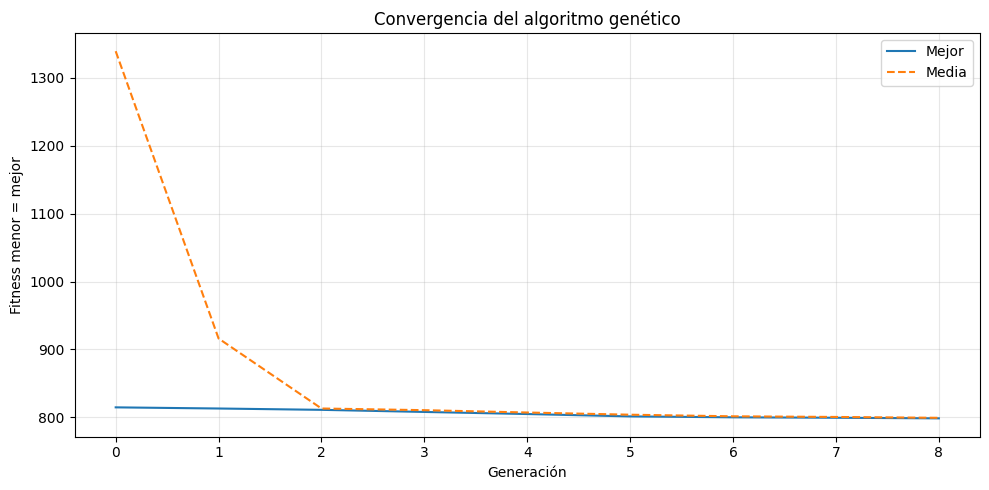

Gantt guardado en: /opt/projects/tfm/algoritmos/output/ga_gantt.png


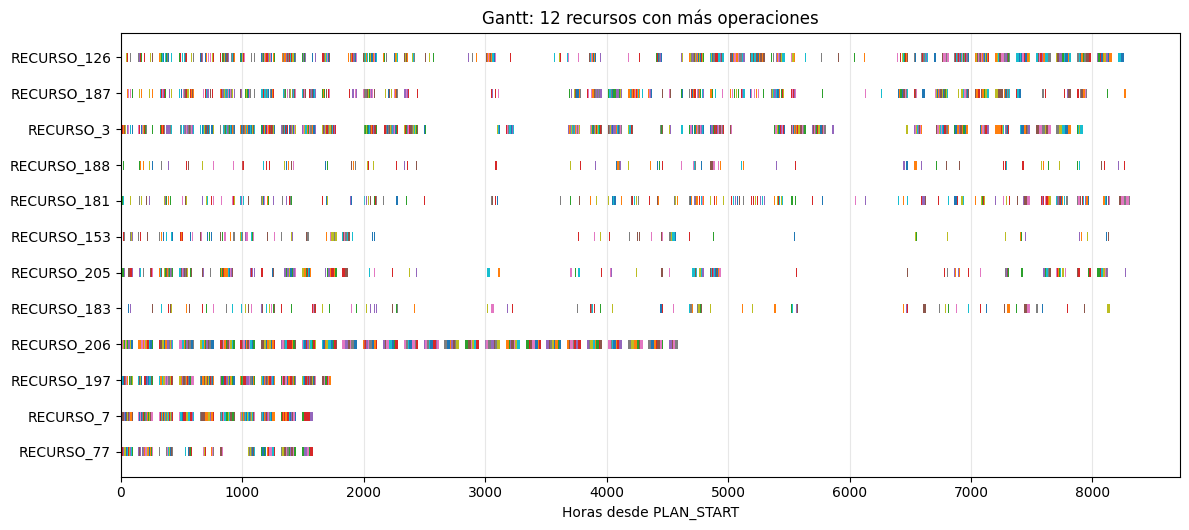

Gantt de maquinas extremas guardado en: /opt/projects/tfm/algoritmos/output/ga_gantt_extremos.png


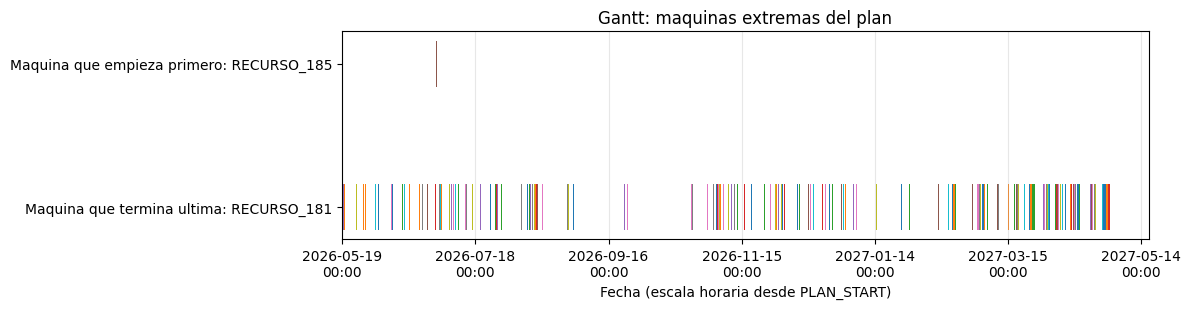

In [15]:
if len(logdf):
    fig, ax = plt.subplots(figsize=(10, 5))
    ax.plot(logdf["gen"], logdf["best"], label="Mejor")
    ax.plot(logdf["gen"], logdf["avg"], label="Media", linestyle="--")
    ax.set_xlabel("Generación")
    ax.set_ylabel("Fitness menor = mejor")
    ax.set_title("Convergencia del algoritmo genético")
    ax.grid(True, alpha=0.3)
    ax.legend()
    plt.tight_layout()
    convergence_path = OUTPUT_DIR / "ga_convergencia.png"
    plt.savefig(convergence_path, dpi=150, bbox_inches="tight")
    print("Gráfico guardado en:", convergence_path)
    plt.show()

# Gantt de los recursos más cargados.
if len(out_df):
    gantt_df = out_df.copy()
    gantt_df["RECURSO"] = gantt_df["RECURSO"].astype(str)
    gantt_df["COMIENZO_OPERACION_DT"] = pd.to_datetime(gantt_df["COMIENZO_OPERACION"])
    gantt_df["FIN_OPERACION_DT"] = pd.to_datetime(gantt_df["FIN_OPERACION"])

    def configurar_eje_horas_como_fechas(ax, inicio_plan, min_h, max_h):
        rango_h = max(float(max_h) - float(min_h), 1.0)
        pasos_h = [1, 2, 4, 8, 12, 24, 48, 72, 168, 336, 720, 1440]
        paso_h = next((p for p in pasos_h if rango_h / p <= 8), pasos_h[-1])
        tick_inicio = math.floor(float(min_h) / paso_h) * paso_h
        ticks = np.arange(tick_inicio, float(max_h) + paso_h, paso_h)
        ax.set_xticks(ticks)
        ax.xaxis.set_major_formatter(
            FuncFormatter(
                lambda h, _pos: (inicio_plan + pd.to_timedelta(float(h), unit="h")).strftime("%Y-%m-%d\n%H:%M")
            )
        )

    top_recursos = gantt_df.groupby("RECURSO").size().sort_values(ascending=False).head(12).index.tolist()
    sub = gantt_df[gantt_df["RECURSO"].isin(top_recursos)].copy()

    fig, ax = plt.subplots(figsize=(12, max(5, len(top_recursos) * 0.45)))
    y_map = {r: i for i, r in enumerate(reversed(top_recursos))}
    for _, row in sub.iterrows():
        y = y_map[row["RECURSO"]]
        start_h = (row["COMIENZO_OPERACION_DT"] - PLAN_START).total_seconds() / 3600.0
        dur_h = (row["FIN_OPERACION_DT"] - row["COMIENZO_OPERACION_DT"]).total_seconds() / 3600.0
        ax.barh(y, max(dur_h, 0.01), left=start_h, height=0.25)
    ax.set_yticks(list(range(len(top_recursos))))
    ax.set_yticklabels(reversed(top_recursos))
    ax.set_xlabel("Horas desde PLAN_START")
    ax.set_title("Gantt: 12 recursos con más operaciones")
    ax.grid(True, axis="x", alpha=0.3)
    plt.tight_layout()
    gantt_path = OUTPUT_DIR / "ga_gantt.png"
    plt.savefig(gantt_path, dpi=150, bbox_inches="tight")
    print("Gantt guardado en:", gantt_path)
    plt.show()

    # Gantt de dos filas: maquina que empieza primero y maquina que termina ultima.
    recurso_primero = gantt_df.loc[gantt_df["COMIENZO_OPERACION_DT"].idxmin(), "RECURSO"]
    recurso_ultimo = gantt_df.loc[gantt_df["FIN_OPERACION_DT"].idxmax(), "RECURSO"]
    recursos_extremos = [
        ("Maquina que empieza primero", recurso_primero),
        ("Maquina que termina ultima", recurso_ultimo),
    ]

    fig, ax = plt.subplots(figsize=(12, 3.2))
    min_h, max_h = math.inf, -math.inf
    for y, (_rol, recurso) in enumerate(recursos_extremos):
        sub_extremo = gantt_df[gantt_df["RECURSO"] == recurso].sort_values("COMIENZO_OPERACION_DT")
        for _, row in sub_extremo.iterrows():
            start_h = (row["COMIENZO_OPERACION_DT"] - PLAN_START).total_seconds() / 3600.0
            end_h = (row["FIN_OPERACION_DT"] - PLAN_START).total_seconds() / 3600.0
            dur_h = end_h - start_h
            min_h = min(min_h, start_h)
            max_h = max(max_h, end_h)
            ax.barh(y, max(dur_h, 0.01), left=start_h, height=0.32)

    ax.set_yticks(list(range(len(recursos_extremos))))
    ax.set_yticklabels([f"{rol}: {recurso}" for rol, recurso in recursos_extremos])
    ax.invert_yaxis()
    configurar_eje_horas_como_fechas(ax, PLAN_START, min_h, max_h)
    ax.set_xlabel("Fecha (escala horaria desde PLAN_START)")
    ax.set_title("Gantt: maquinas extremas del plan")
    ax.grid(True, axis="x", alpha=0.3)
    plt.tight_layout()
    gantt_extremos_path = OUTPUT_DIR / "ga_gantt_extremos.png"
    plt.savefig(gantt_extremos_path, dpi=150, bbox_inches="tight")
    print("Gantt de maquinas extremas guardado en:", gantt_extremos_path)
    plt.show()

## Conclusión técnica

La planificación resultante es válida si la celda de validación devuelve `valido = True`. Las métricas principales que se exportan y se comparan son:

- `makespan_days`: duración total del plan.
- `tardy_orders`: órdenes que terminan después de `FECHA_PROVEEDOR`.
- `on_time_rate`: porcentaje de órdenes a tiempo.
- `on_time_workload_rate`: porcentaje de carga de trabajo, en horas, que pertenece a órdenes terminadas a tiempo.
- `total_late_days` y `max_late_days`: tardanza total y máxima.
- `utilization`: utilización media de los recursos activos.
- `n_ops_scheduled`: operaciones planificadas.
- `tiempo_ejecucion_ga_min`: tiempo total de ejecución del algoritmo genético en minutos, con 2 decimales.
- `HORAS_TRABAJO_DIA` y `TRABAJA_FINES_SEMANA`: calendario laboral aplicado al cálculo y a la exportación del plan.
- `solapes_recurso` y `errores_precedencia`: validadores de restricciones duras.
- `ga_ordenes_fuera_fecha.csv`: listado de órdenes cuya última operación termina después de `FECHA_PROVEEDOR`.

El parámetro `PESO_FECHA` permite priorizar cumplimiento de fechas frente a makespan. Por defecto vale `0.85`, por lo que se penaliza mucho más incumplir fechas que terminar unas horas antes o después el conjunto total.

## 16. Comparativa extendida con Critical Ratio

In [16]:
# Heurística CR (Critical Ratio) añadida como referencia adicional.
def cr_permutation(order_operations):
    def remaining_work(idx):
        return sum(min(a["dur_total"] for a in op["alternativas"]) for op in order_operations[idx]["ops"])

    rows = []
    for idx, od in order_operations.items():
        deadline = pd.Timestamp(od["deadline"]) if pd.notna(od["deadline"]) else pd.Timestamp.max
        time_to_due_min = (deadline - PLAN_START).total_seconds() / 60.0 if deadline != pd.Timestamp.max else float("inf")
        work = max(remaining_work(idx), 1.0)
        cr = time_to_due_min / work
        rows.append((idx, cr, deadline))
    # CR menor implica mayor urgencia; negativos ya están vencidos.
    return [idx for idx, _, _ in sorted(rows, key=lambda x: (x[1], x[2], x[0]))]

comparativa_ext = pd.concat([
    comparativa,
    pd.DataFrame([evaluar_secuencia("CR", cr_permutation(order_operations))])[cols],
], ignore_index=True)
comparativa_ext_path = OUTPUT_DIR / "ga_comparativa_metricas_extendida.csv"
comparativa_ext.to_csv(comparativa_ext_path, sep=";", index=False)
print("Comparativa extendida guardada en:", comparativa_ext_path)
comparativa_ext

Comparativa extendida guardada en: /opt/projects/tfm/algoritmos/output/ga_comparativa_metricas_extendida.csv


,metodo,fitness,makespan_days,tardy_orders,due_orders,on_time_rate,workload_hours,on_time_workload_hours,on_time_workload_rate,total_late_days,max_late_days,utilization,n_ops_scheduled,n_active_res,missing_ops
0,GA,798.349555,248.076475,1233,2328,0.470361,94601.197670,18315.481891,0.193607,79413.230553,246.952700,0.112689,10641,141,0
1,EDD,1566.822323,245.750865,2211,2328,0.050258,94528.883040,4051.888329,0.042864,194553.807730,144.980794,0.114480,10641,140,0
2,SPT,814.570492,251.827841,1247,2328,0.464347,94618.197262,17706.057314,0.187132,82214.412089,250.704067,0.111030,10641,141,0
3,CR,1837.769367,232.635397,2235,2328,0.039948,94624.832698,6270.646259,0.066269,265213.505259,217.434860,0.119352,10641,142,0


## 17. Análisis ampliado por orden y por recurso

Estas tablas permiten validar el comportamiento del AG con métricas habituales en scheduling: tardanza por orden, finalización, flujo, carga por recurso y utilización. Sirven para comparar contra Asprova o contra diferentes configuraciones del AG.

In [17]:
# Métricas por orden.
workload_by_order_min = defaultdict(float)
for s in best_sch:
    workload_by_order_min[s["oidx"]] += max(0.0, s["t_end"] - s["t_start"])

order_rows = []
finish_by_order = {idx: finish for idx, finish in best_of.items()}
for idx, od in order_operations.items():
    finish_min = finish_by_order.get(idx, math.inf)
    if math.isfinite(finish_min):
        finish_dt = fecha_plan_desde_minutos_laborales(finish_min)
    else:
        finish_dt = pd.NaT
    deadline = pd.Timestamp(od["deadline"]) if pd.notna(od["deadline"]) else pd.NaT
    deadline_work_min = od.get("deadline_work_min", math.inf)
    late_min = max(0.0, float(finish_min) - float(deadline_work_min)) if math.isfinite(finish_min) and math.isfinite(deadline_work_min) else math.inf
    order_rows.append({
        "ORDEN": od["orden"],
        "PARTNUMBER": od["pn"],
        "CANTIDAD": od["qty"],
        "N_OPERACIONES": od["n_ops"],
        "CARGA_TRABAJO_HORAS": workload_by_order_min.get(idx, 0.0) / 60.0,
        "FECHA_PROVEEDOR": deadline,
        "FIN_PLANIFICADO": finish_dt,
        "TARDANZA_MIN": late_min,
        "TARDANZA_DIAS": late_min / max(MINUTOS_TRABAJO_DIA, 1.0) if math.isfinite(late_min) else math.inf,
        "A_TIEMPO": bool(late_min <= 0),
    })

orden_metricas_df = pd.DataFrame(order_rows).sort_values(["A_TIEMPO", "TARDANZA_MIN"], ascending=[True, False])
orden_metricas_path = OUTPUT_DIR / "ga_metricas_por_orden.csv"
orden_metricas_df.to_csv(orden_metricas_path, sep=";", index=False)

ordenes_fuera_fecha_df = orden_metricas_df[~orden_metricas_df["A_TIEMPO"]].copy()
ordenes_fuera_fecha_path = OUTPUT_DIR / "ga_ordenes_fuera_fecha.csv"
ordenes_fuera_fecha_df.to_csv(ordenes_fuera_fecha_path, sep=";", index=False)

carga_total_horas = orden_metricas_df["CARGA_TRABAJO_HORAS"].sum()
carga_en_fecha_horas = orden_metricas_df.loc[orden_metricas_df["A_TIEMPO"], "CARGA_TRABAJO_HORAS"].sum()
ordenes_totales = len(orden_metricas_df)
ordenes_en_fecha = int(orden_metricas_df["A_TIEMPO"].sum())
metricas_cumplimiento_fechas_df = pd.DataFrame([{
    "ordenes_totales": ordenes_totales,
    "ordenes_en_fecha": ordenes_en_fecha,
    "ordenes_fuera_fecha": int(len(ordenes_fuera_fecha_df)),
    "porcentaje_ordenes_en_fecha": (ordenes_en_fecha / ordenes_totales * 100.0) if ordenes_totales else 0.0,
    "carga_total_horas": carga_total_horas,
    "carga_en_fecha_horas": carga_en_fecha_horas,
    "carga_fuera_fecha_horas": carga_total_horas - carga_en_fecha_horas,
    "porcentaje_carga_horas_en_fecha": (carga_en_fecha_horas / carga_total_horas * 100.0) if carga_total_horas else 0.0,
}])
metricas_cumplimiento_fechas_path = OUTPUT_DIR / "ga_metricas_cumplimiento_fechas.csv"
metricas_cumplimiento_fechas_df.to_csv(metricas_cumplimiento_fechas_path, sep=";", index=False)

print("Métricas por orden guardadas en:", orden_metricas_path)
print("Órdenes fuera de fecha guardadas en:", ordenes_fuera_fecha_path)
print("Métricas de cumplimiento de fechas guardadas en:", metricas_cumplimiento_fechas_path)
display(metricas_cumplimiento_fechas_df)
display(orden_metricas_df.head(20))
display(ordenes_fuera_fecha_df.head(20))

# Métricas por recurso.
res_df = out_df.copy()
res_df["COMIENZO_OPERACION_DT"] = pd.to_datetime(res_df["COMIENZO_OPERACION"])
res_df["FIN_OPERACION_DT"] = pd.to_datetime(res_df["FIN_OPERACION"])
res_df["DURACION_MIN"] = (res_df["FIN_OPERACION_DT"] - res_df["COMIENZO_OPERACION_DT"]).dt.total_seconds() / 60.0
makespan_min = best_met["makespan_min"]
recurso_metricas_df = (
    res_df.groupby(["GRUPO_RECURSO", "RECURSO"], as_index=False)
    .agg(
        operaciones=("ORDEN", "count"),
        carga_min=("DURACION_MIN", "sum"),
        comienzo=("COMIENZO_OPERACION_DT", "min"),
        fin=("FIN_OPERACION_DT", "max"),
    )
)
recurso_metricas_df["utilizacion_sobre_makespan"] = recurso_metricas_df["carga_min"] / makespan_min
recurso_metricas_df = recurso_metricas_df.sort_values("carga_min", ascending=False)
recurso_metricas_path = OUTPUT_DIR / "ga_metricas_por_recurso.csv"
recurso_metricas_df.to_csv(recurso_metricas_path, sep=";", index=False)
print("Métricas por recurso guardadas en:", recurso_metricas_path)
display(recurso_metricas_df.head(20))

Métricas por orden guardadas en: /opt/projects/tfm/algoritmos/output/ga_metricas_por_orden.csv
Órdenes fuera de fecha guardadas en: /opt/projects/tfm/algoritmos/output/ga_ordenes_fuera_fecha.csv
Métricas de cumplimiento de fechas guardadas en: /opt/projects/tfm/algoritmos/output/ga_metricas_cumplimiento_fechas.csv


,ordenes_totales,ordenes_en_fecha,ordenes_fuera_fecha,porcentaje_ordenes_en_fecha,carga_total_horas,carga_en_fecha_horas,carga_fuera_fecha_horas,porcentaje_carga_horas_en_fecha
0,2328,1095,1233,47.036082,94601.19767,18315.481891,76285.715779,19.360729


,ORDEN,PARTNUMBER,CANTIDAD,N_OPERACIONES,CARGA_TRABAJO_HORAS,FECHA_PROVEEDOR,FIN_PLANIFICADO,TARDANZA_MIN,TARDANZA_DIAS,A_TIEMPO
1881,ORDEN_11935,PARTNUMBER_1510,495.0,5,441.608982,2026-05-19,2027-04-28 22:51:53.306976708,355611.888450,246.952700,False
1444,ORDEN_9209,PARTNUMBER_1932,6.0,12,243.994982,2026-05-25,2027-04-13 00:32:28.601094360,332672.476685,231.022553,False
485,ORDEN_3964,PARTNUMBER_2769,6.0,10,221.249238,2026-05-22,2027-04-09 01:31:18.012859068,331291.300214,230.063403,False
1407,ORDEN_9063,PARTNUMBER_499,6.0,10,218.349491,2026-05-22,2027-04-02 11:57:36.686655846,324717.611444,225.498341,False
1403,ORDEN_9043,PARTNUMBER_420,8.0,12,320.956246,2026-06-11,2027-04-22 06:36:00.365800236,324396.006097,225.275004,False
1703,ORDEN_10475,PARTNUMBER_1984,6.0,10,219.465704,2026-06-01,2027-04-07 02:12:54.333714666,319812.905562,222.092296,False
360,ORDEN_3107,PARTNUMBER_2272,14.0,9,214.451909,2026-05-26,2027-03-31 15:38:47.274891138,319178.787915,221.651936,False
306,ORDEN_2636,PARTNUMBER_1939,7.0,11,257.030343,2026-06-08,2027-04-13 13:48:56.836388478,319068.947273,221.575658,False
158,ORDEN_1514,PARTNUMBER_1238,6.0,9,237.413100,2026-06-08,2027-04-12 06:21:53.306976714,317181.888450,220.265200,False
432,ORDEN_3521,PARTNUMBER_2516,8.0,13,201.884645,2026-05-30,2027-03-31 05:17:36.686655846,312797.611444,217.220564,False


,ORDEN,PARTNUMBER,CANTIDAD,N_OPERACIONES,CARGA_TRABAJO_HORAS,FECHA_PROVEEDOR,FIN_PLANIFICADO,TARDANZA_MIN,TARDANZA_DIAS,A_TIEMPO
1881,ORDEN_11935,PARTNUMBER_1510,495.0,5,441.608982,2026-05-19,2027-04-28 22:51:53.306976708,355611.888450,246.952700,False
1444,ORDEN_9209,PARTNUMBER_1932,6.0,12,243.994982,2026-05-25,2027-04-13 00:32:28.601094360,332672.476685,231.022553,False
485,ORDEN_3964,PARTNUMBER_2769,6.0,10,221.249238,2026-05-22,2027-04-09 01:31:18.012859068,331291.300214,230.063403,False
1407,ORDEN_9063,PARTNUMBER_499,6.0,10,218.349491,2026-05-22,2027-04-02 11:57:36.686655846,324717.611444,225.498341,False
1403,ORDEN_9043,PARTNUMBER_420,8.0,12,320.956246,2026-06-11,2027-04-22 06:36:00.365800236,324396.006097,225.275004,False
1703,ORDEN_10475,PARTNUMBER_1984,6.0,10,219.465704,2026-06-01,2027-04-07 02:12:54.333714666,319812.905562,222.092296,False
360,ORDEN_3107,PARTNUMBER_2272,14.0,9,214.451909,2026-05-26,2027-03-31 15:38:47.274891138,319178.787915,221.651936,False
306,ORDEN_2636,PARTNUMBER_1939,7.0,11,257.030343,2026-06-08,2027-04-13 13:48:56.836388478,319068.947273,221.575658,False
158,ORDEN_1514,PARTNUMBER_1238,6.0,9,237.413100,2026-06-08,2027-04-12 06:21:53.306976714,317181.888450,220.265200,False
432,ORDEN_3521,PARTNUMBER_2516,8.0,13,201.884645,2026-05-30,2027-03-31 05:17:36.686655846,312797.611444,217.220564,False


Métricas por recurso guardadas en: /opt/projects/tfm/algoritmos/output/ga_metricas_por_recurso.csv


,GRUPO_RECURSO,RECURSO,operaciones,carga_min,comienzo,fin,utilizacion_sobre_makespan
4,GRUPO_RECURSO_1,RECURSO_3,927,206104.016667,2026-05-19 00:33:27,2027-04-14 05:56:16,0.576950
116,GRUPO_RECURSO_43,RECURSO_126,1559,198264.916667,2026-05-19 00:10:19,2027-04-28 00:51:18,0.555006
127,GRUPO_RECURSO_50,RECURSO_206,261,196790.350000,2026-05-19 03:33:00,2026-11-26 00:47:01,0.550878
51,GRUPO_RECURSO_137,RECURSO_96,158,158750.950000,2026-05-20 06:22:52,2026-10-27 14:04:43,0.444394
82,GRUPO_RECURSO_2,RECURSO_192,149,106121.850000,2026-05-19 00:00:00,2026-08-31 22:01:17,0.297069
40,GRUPO_RECURSO_128,RECURSO_139,79,100786.483333,2026-05-19 00:46:56,2026-09-15 05:36:57,0.282133
108,GRUPO_RECURSO_4,RECURSO_181,575,96787.216667,2026-05-19 00:00:00,2027-04-30 01:50:07,0.270938
83,GRUPO_RECURSO_2,RECURSO_99,129,95967.500000,2026-05-19 00:00:00,2026-08-21 17:45:55,0.268643
81,GRUPO_RECURSO_2,RECURSO_180,138,95887.316667,2026-05-19 00:00:00,2026-09-02 07:38:50,0.268419
165,GRUPO_RECURSO_8,RECURSO_58,176,89969.633333,2026-05-19 00:00:00,2026-08-26 23:26:20,0.251853


## 18. Resumen trazable del experimento

In [18]:
# Resumen de experimento en JSON para trazabilidad.
def resumen_operacion_planificada(op, instante):
    if op is None:
        return None
    campo_minuto = "t_start" if instante == "inicio" else "t_end"
    campo_fecha = "fecha_hora_inicio" if instante == "inicio" else "fecha_hora_fin"
    campo_minuto_resumen = "minuto_laboral_inicio" if instante == "inicio" else "minuto_laboral_fin"
    fecha = fecha_plan_desde_minutos_laborales(op[campo_minuto], como_fin=(instante == "fin"))
    return {
        campo_fecha: fmt_ts(fecha),
        "recurso": str(op["RECURSO"]),
        "grupo_recurso": str(op["GRUPO_RECURSO"]),
        "orden": str(op["ORDEN"]),
        "operacion": int(op["OPERACION"]),
        "partnumber": str(op["PARTNUMBER"]),
        campo_minuto_resumen: float(op[campo_minuto]),
        "duracion_minutos": round(float(op["t_end"] - op["t_start"]), 6),
    }

primera_operacion = None
ultima_operacion = None
if best_sch:
    primera_operacion = min(
        best_sch,
        key=lambda s: (s["t_start"], s["t_end"], str(s["RECURSO"]), str(s["ORDEN"]), int(s["OPERACION"])),
    )
    ultima_operacion = max(
        best_sch,
        key=lambda s: (s["t_end"], s["t_start"], str(s["RECURSO"]), str(s["ORDEN"]), int(s["OPERACION"])),
    )

primera_operacion_planificada = resumen_operacion_planificada(primera_operacion, "inicio")
ultima_operacion_planificada = resumen_operacion_planificada(ultima_operacion, "fin")

experimento = {
    "nombre": "aps_genetico_mejorado",
    "root_dir": str(ROOT_DIR),
    "data_dir": str(DATA_DIR),
    "output_dir": str(OUTPUT_DIR),
    "plan_start": str(PLAN_START),
    "random_seed": RANDOM_SEED,
    "parametros_ga": {
        "PESO_FECHA": PESO_FECHA,
        "POP_SIZE": POP_SIZE,
        "OFFSPRING_PER_GEN": OFFSPRING_PER_GEN,
        "MAX_GEN": MAX_GEN,
        "CX_PB": CX_PB,
        "MUT_PB": MUT_PB,
        "ELITE_SIZE": ELITE_SIZE,
        "HORAS_TRABAJO_DIA": HORAS_TRABAJO_DIA,
        "TRABAJA_FINES_SEMANA": TRABAJA_FINES_SEMANA,
        "HORA_INICIO_TURNO": HORA_INICIO_TURNO,
        "MODO_PLANIFICACION_ORDENES": MODO_PLANIFICACION_ORDENES,
        "ELIMINAR_ORDENES_FECHA_PROVEEDOR_ATRASADA": ELIMINAR_ORDENES_FECHA_PROVEEDOR_ATRASADA,
    },
    "datos": {
        "ordenes_plan_originales": n_plan_original,
        "ordenes_fuera_lpa": n_ordenes_plan_fuera_lpa,
        "ordenes_descartadas_por_modo_lpa": len(ordenes_plan_fuera_lpa),
        "ordenes_planificables": len(order_operations),
        "ordenes_omitidas": len(skipped_orders),
        "segmentos_planificados": int(len(out_df)),
        "operaciones_planificadas_unicas": int(out_df[["ORDEN", "OPERACION"]].drop_duplicates().shape[0]),
        "recursos": int(recursos_df["RECURSO"].nunique()),
        "grupos_recurso": int(recursos_df["GRUPO_RECURSO"].nunique()),
    },
    "ventana_planificada": {
        "unidad_tiempos_schedule": "minutos_laborales",
        "primera_operacion": primera_operacion_planificada,
        "ultima_operacion": ultima_operacion_planificada,
    },
    "mejor_metricas": best_met,
    "validacion": validation,
}
experimento_path = OUTPUT_DIR / "ga_resumen_experimento_aps.json"
with open(experimento_path, "w", encoding="utf-8") as f:
    json.dump(experimento, f, ensure_ascii=False, indent=2, default=str)
print("Resumen de experimento guardado en:", experimento_path)

# Métricas generales
print("\n" + "="*60)
print("MÉTRICAS GENERALES DEL EXPERIMENTO")
print("="*60)
tiempo_ejecucion = best_met.get('tiempo_ejecucion_ga_min', 0.0)
print(f"⏱️  Tiempo de ejecución del algoritmo: {tiempo_ejecucion:.2f} minutos")

pct_ordenes_en_fecha = best_met.get('on_time_rate', 0.0) * 100
print(f"📦 Porcentaje de órdenes completadas en fecha: {pct_ordenes_en_fecha:.2f}%")

pct_carga_en_fecha = best_met.get('on_time_workload_rate', 0.0) * 100
print(f"⚙️  Porcentaje de carga de trabajo completado en fecha: {pct_carga_en_fecha:.2f}%")

if primera_operacion_planificada is not None:
    print(
        "Primera operación planificada: "
        f"{primera_operacion_planificada['fecha_hora_inicio']} "
        f"en recurso {primera_operacion_planificada['recurso']}"
    )
if ultima_operacion_planificada is not None:
    print(
        "Fin de la última operación planificada: "
        f"{ultima_operacion_planificada['fecha_hora_fin']} "
        f"en recurso {ultima_operacion_planificada['recurso']}"
    )


Resumen de experimento guardado en: /opt/projects/tfm/algoritmos/output/ga_resumen_experimento_aps.json

MÉTRICAS GENERALES DEL EXPERIMENTO
⏱️  Tiempo de ejecución del algoritmo: 0.16 minutos
📦 Porcentaje de órdenes completadas en fecha: 47.04%
⚙️  Porcentaje de carga de trabajo completado en fecha: 19.36%
Primera operación planificada: 2026-05-19 00:00:00.000 en recurso RECURSO_56
Fin de la última operación planificada: 2027-04-30 01:50:07.000 en recurso RECURSO_181


## 19. Simulaciones extremas de peso de fechas

Se ejecutan dos simulaciones adicionales solo en memoria, sin regenerar graficas ni ficheros de salida: una con `PESO_FECHA = 1.0` y otra con `PESO_FECHA = 0.0`.

In [19]:
import contextlib
import io


def simular_ga_con_peso_fecha(peso_fecha_simulado):
    global PESO_FECHA

    peso_original = PESO_FECHA
    try:
        PESO_FECHA = float(peso_fecha_simulado)
        random.seed(RANDOM_SEED)
        np.random.seed(RANDOM_SEED)

        # Ejecutar solo la simulacion: no se escriben CSV/JSON ni se generan graficas.
        with contextlib.redirect_stdout(io.StringIO()):
            sim_best_chrom, sim_best_score, sim_best_met, _ = ejecutar_ga()

        sim_best_sch, _, _, sim_best_missing = decode_schedule(
            sim_best_chrom,
            order_operations,
            recursos_por_grupo,
        )

        primera_sim = None
        ultima_sim = None
        if sim_best_sch:
            primera_sim = min(
                sim_best_sch,
                key=lambda s: (s["t_start"], s["t_end"], str(s["RECURSO"]), str(s["ORDEN"]), int(s["OPERACION"])),
            )
            ultima_sim = max(
                sim_best_sch,
                key=lambda s: (s["t_end"], s["t_start"], str(s["RECURSO"]), str(s["ORDEN"]), int(s["OPERACION"])),
            )

        primera_planificada_sim = resumen_operacion_planificada(primera_sim, "inicio")
        ultima_planificada_sim = resumen_operacion_planificada(ultima_sim, "fin")

        pct_ordenes_en_fecha = sim_best_met.get("on_time_rate", 0.0) * 100
        pct_carga_en_fecha = sim_best_met.get("on_time_workload_rate", 0.0) * 100

        print("\n" + "="*60)
        print(f"RESUMEN SIMULACION GA CON PESO_FECHA = {PESO_FECHA:.2f}")
        print("="*60)
        print(f"Fitness: {sim_best_score:.4f}")
        print(f"Tiempo de ejecucion del algoritmo: {sim_best_met.get('tiempo_ejecucion_ga_min', 0.0):.2f} minutos")
        print(f"Ordenes fuera de fecha: {sim_best_met.get('tardy_orders', 0)} de {sim_best_met.get('due_orders', len(order_operations))}")
        print(f"Porcentaje de ordenes completadas en fecha: {pct_ordenes_en_fecha:.2f}%")
        print(f"Porcentaje de carga de trabajo completado en fecha: {pct_carga_en_fecha:.2f}%")
        print(f"Duracion global del plan: {sim_best_met.get('makespan_days', 0.0):.2f} dias laborales")
        print(f"Operaciones sin planificar: {len(sim_best_missing)}")

        if primera_planificada_sim is not None:
            print(
                "Primera operacion planificada: "
                f"{primera_planificada_sim['fecha_hora_inicio']} "
                f"en recurso {primera_planificada_sim['recurso']}"
            )
        if ultima_planificada_sim is not None:
            print(
                "Fin de la ultima operacion planificada: "
                f"{ultima_planificada_sim['fecha_hora_fin']} "
                f"en recurso {ultima_planificada_sim['recurso']}"
            )

        return {
            "peso_fecha": PESO_FECHA,
            "best_chrom": sim_best_chrom,
            "best_score": sim_best_score,
            "best_metricas": sim_best_met,
            "primera_operacion": primera_planificada_sim,
            "ultima_operacion": ultima_planificada_sim,
            "operaciones_sin_planificar": len(sim_best_missing),
        }
    finally:
        PESO_FECHA = peso_original


simulacion_peso_fecha_1 = simular_ga_con_peso_fecha(1.0)
simulacion_peso_fecha_0 = simular_ga_con_peso_fecha(0.0)



RESUMEN SIMULACION GA CON PESO_FECHA = 1.00
Fitness: 891.5891
Tiempo de ejecucion del algoritmo: 0.17 minutos
Ordenes fuera de fecha: 1222 de 2328
Porcentaje de ordenes completadas en fecha: 47.51%
Porcentaje de carga de trabajo completado en fecha: 19.71%
Duracion global del plan: 249.20 dias laborales
Operaciones sin planificar: 0
Primera operacion planificada: 2026-05-19 00:00:00.000 en recurso RECURSO_56
Fin de la ultima operacion planificada: 2027-05-03 04:44:54.000 en recurso RECURSO_181

RESUMEN SIMULACION GA CON PESO_FECHA = 0.00
Fitness: 202.8766
Tiempo de ejecucion del algoritmo: 0.17 minutos
Ordenes fuera de fecha: 1830 de 2328
Porcentaje de ordenes completadas en fecha: 21.39%
Porcentaje de carga de trabajo completado en fecha: 22.28%
Duracion global del plan: 202.88 dias laborales
Operaciones sin planificar: 0
Primera operacion planificada: 2026-05-19 00:00:00.000 en recurso RECURSO_33
Fin de la ultima operacion planificada: 2027-02-25 21:02:21.000 en recurso RECURSO_3


In [20]:
# JSON comparativo: experimento inicial y simulaciones extremas.
def preparar_metricas_comparacion(metricas):
    if metricas is None:
        return None
    excluir = {"best_chrom", "chromosome", "schedule"}
    return {k: v for k, v in metricas.items() if k not in excluir}


def preparar_simulacion_comparacion(nombre, simulacion, metricas_fallback=None, ventana_fallback=None, parametros_extra=None):
    sim = simulacion or {}
    metricas = preparar_metricas_comparacion(sim.get("best_metricas", metricas_fallback))
    best_score_sim = sim.get("best_score", best_score if metricas_fallback is best_met else None)
    if metricas is not None and "fitness" not in metricas and best_score_sim is not None:
        metricas["fitness"] = best_score_sim
    secuencia = sim.get("best_chrom") or []
    return {
        "nombre": nombre,
        "peso_fecha": sim.get("peso_fecha", PESO_FECHA),
        "best_score": best_score_sim,
        "secuencia_oidx": [int(x) for x in secuencia],
        "metricas": metricas,
        "ventana_planificada": {
            "primera_operacion": sim.get("primera_operacion") or (ventana_fallback or {}).get("primera_operacion"),
            "ultima_operacion": sim.get("ultima_operacion") or (ventana_fallback or {}).get("ultima_operacion"),
        },
        "operaciones_sin_planificar": sim.get("operaciones_sin_planificar", (metricas or {}).get("missing_ops")),
        "parametros_extra": parametros_extra or {},
    }


resumen_comparativo = {
    "nombre": "aps_genetico",
    "archivo_origen": "aps_genetico.ipynb",
    "descripcion": "Resumen comparable del experimento inicial y simulaciones extremas de PESO_FECHA.",
    "root_dir": str(ROOT_DIR),
    "data_dir": str(DATA_DIR),
    "output_dir": str(OUTPUT_DIR),
    "plan_start": str(PLAN_START),
    "random_seed": RANDOM_SEED,
    "parametros": experimento.get("parametros_ga", {}),
    "datos": experimento.get("datos", {}),
    "validacion": experimento.get("validacion", {}),
    "simulaciones": {
        "inicial": preparar_simulacion_comparacion(
            "inicial",
            {
                "peso_fecha": PESO_FECHA,
                "best_score": best_score,
                "best_chrom": best_chrom,
                "best_metricas": best_met,
                "primera_operacion": primera_operacion_planificada,
                "ultima_operacion": ultima_operacion_planificada,
                "operaciones_sin_planificar": best_met.get("missing_ops"),
            },
            metricas_fallback=best_met,
            ventana_fallback=experimento.get("ventana_planificada", {}),
        ),
        "peso_fecha_1": preparar_simulacion_comparacion(
            "peso_fecha_1",
            simulacion_peso_fecha_1,
            parametros_extra={"objetivo": "solo penalizacion de fechas/tardanza"},
        ),
        "peso_fecha_0": preparar_simulacion_comparacion(
            "peso_fecha_0",
            simulacion_peso_fecha_0,
            parametros_extra={"objetivo": "solo makespan"},
        ),
    },
}

resumen_comparativo_path = OUTPUT_DIR / "ga_resumen_comparativo_simulaciones.json"
with open(resumen_comparativo_path, "w", encoding="utf-8") as f:
    json.dump(resumen_comparativo, f, ensure_ascii=False, indent=2, default=str)

print("Resumen comparativo guardado en:", resumen_comparativo_path)





Resumen comparativo guardado en: /opt/projects/tfm/algoritmos/output/ga_resumen_comparativo_simulaciones.json


## Conclusión de la versión mejorada

Esta versión es más completa para análisis porque no solo genera la secuencia, sino que deja trazabilidad del experimento y métricas detalladas por orden y por recurso. Es la versión recomendada para comparar configuraciones del AG, pesos de objetivo o subconjuntos de datos.